# Phase 4: Model Development — Supply Chain ML

### Table of Contents
1. Setup & Load Feature Data  
2. Regression — Procurement Cost  
3. Regression — Profit Margin  
4. Classification — Shipment Delay  
5. Classification — High Defect Flag  
6. Clustering — Supplier Segmentation  
7. Clustering — Customer Segmentation  
8. Model Comparison Summary  

---
## 1. Setup & Load Feature Data

In [1]:
#  Core   
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

#  Visualisation   
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import seaborn as sns

#  Preprocessing   
from sklearn.model_selection     import train_test_split
from sklearn.preprocessing       import StandardScaler
from sklearn.impute               import SimpleImputer

#  Regression  
from sklearn.linear_model        import LinearRegression, Ridge, Lasso
from sklearn.ensemble            import RandomForestRegressor
from xgboost                     import XGBRegressor

#  Classification  
from sklearn.linear_model        import LogisticRegression
from sklearn.ensemble            import RandomForestClassifier, GradientBoostingClassifier

#  Clustering  
from sklearn.cluster             import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy     import dendrogram, linkage
from sklearn.decomposition       import PCA

#  Metrics  
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, silhouette_score
)

import os


LIGHT_PALETTE = ['#1f77b4','#2ca02c','#d62728','#9467bd','#ff7f0e',
                  '#17becf','#8c564b','#e377c2','#7f7f7f','#bcbd22']
CMAP_LIGHT     = LinearSegmentedColormap.from_list('light_heat',
                     ['#f7fbff','#c6dbef','#6baed6','#2171b5','#084594'])

print('All libraries loaded. Libraries loaded.')


All libraries loaded. Libraries loaded.


In [2]:
#  Load feature-engineered datasets 

proc_df     = pd.read_csv('features/procurement_regression_features.csv')
sales_df    = pd.read_csv('features/profit_margin_regression_features.csv')
ship_df     = pd.read_csv('features/shipment_delay_classification_features.csv')
prod_df     = pd.read_csv('features/fact_production_engineered.csv')
sup_df      = pd.read_csv('features/supplier_clustering_features.csv')
cust_df     = pd.read_csv('features/customer_clustering_features.csv')

for name, df in [('proc_df', proc_df), ('sales_df', sales_df),
                 ('ship_df', ship_df),  ('sup_df', sup_df),
                 ('cust_df', cust_df)]:
    print(f'{name:12s} -> {df.shape[0]:>7,} rows  x  {df.shape[1]:>2} cols')


proc_df      ->   3,000 rows  x  14 cols
sales_df     ->   3,000 rows  x  14 cols
ship_df      ->  12,000 rows  x  18 cols
sup_df       ->      10 rows  x  12 cols
cust_df      ->       5 rows  x  11 cols


In [3]:
#  Shared helper: evaluate regression  
def eval_regression(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'  {name:35s}  MAE ={mae:>10.2f}  RMSE ={rmse:>10.2f}  R2 = {r2:>6.4f}')
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

#  Shared helper: evaluate classification  
def eval_classification(name, y_true, y_pred, y_prob=None):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else None
    auc_str = f'{auc:.4f}' if auc else '  N/A '
    print(f'  {name:38s}  Acc = {acc:.4f}  Prec = {prec:.4f}  Rec = {rec:.4f}  F1 = {f1:.4f}  AUC = {auc_str}')
    return {'Model': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1': f1, 'AUC': auc}

print('Helper functions defined.')


Helper functions defined.


---
## 2. Regression — Procurement Cost Prediction
**Target:** `total_cost`  
**Models:** Linear Regression, Ridge, Lasso, Random Forest Regressor, XGBoost

In [4]:
#  2.1 Prepare data    
TARGET_PROC = 'total_cost'
X_proc = proc_df.drop(columns=[TARGET_PROC]).select_dtypes(include=[np.number]).copy()
y_proc = proc_df[TARGET_PROC].copy()

# Impute & scale
imputer  = SimpleImputer(strategy='median')
scaler   = StandardScaler()

X_proc_imp    = imputer.fit_transform(X_proc)
X_proc_scaled = scaler.fit_transform(X_proc_imp)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_proc_scaled, y_proc, test_size=0.2, random_state=42
)

print(f'Train: {X_tr.shape}  |  Test: {X_te.shape}')
print(f'Target range: {y_proc.min():.2f} — {y_proc.max():.2f}  |  Mean: {y_proc.mean():.2f}')


Train: (2400, 12)  |  Test: (600, 12)
Target range: 9455.54 — 9793862.78  |  Mean: 2597825.17


In [5]:
#  2.2 Train all regression models   
proc_reg_models = {
    'Linear Regression'    : LinearRegression(),
    'Ridge Regression'     : Ridge(alpha=1.0),
    'Lasso Regression'     : Lasso(alpha=0.1, max_iter=5000),
    'Random Forest Reg.'   : RandomForestRegressor(n_estimators=200, max_depth=10,
                                                    min_samples_leaf=5, random_state=42,
                                                    n_jobs=-1),
    'XGBoost Reg.'         : XGBRegressor(n_estimators=300, learning_rate=0.05,
                                           max_depth=6, subsample=0.8,
                                           colsample_bytree=0.8,
                                           random_state=42, verbosity=0),
}

proc_reg_results  = []
proc_reg_preds    = {}
proc_fi_models    = {}

print('=== Procurement Cost Regression Results ===')
for name, model in proc_reg_models.items():
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    proc_reg_preds[name] = y_pred
    res = eval_regression(name, y_te, y_pred)
    proc_reg_results.append(res)
    if hasattr(model, 'feature_importances_'):
        proc_fi_models[name] = model

proc_reg_df = pd.DataFrame(proc_reg_results).sort_values('R2', ascending=False)


=== Procurement Cost Regression Results ===
  Linear Regression                    MAE =1101499.44  RMSE =1458101.72  R2 = 0.5951
  Ridge Regression                     MAE =1101447.05  RMSE =1458102.85  R2 = 0.5951
  Lasso Regression                     MAE =1101499.33  RMSE =1458101.67  R2 = 0.5951
  Random Forest Reg.                   MAE = 505003.64  RMSE = 745917.75  R2 = 0.8940
  XGBoost Reg.                         MAE = 456693.46  RMSE = 688709.94  R2 = 0.9097


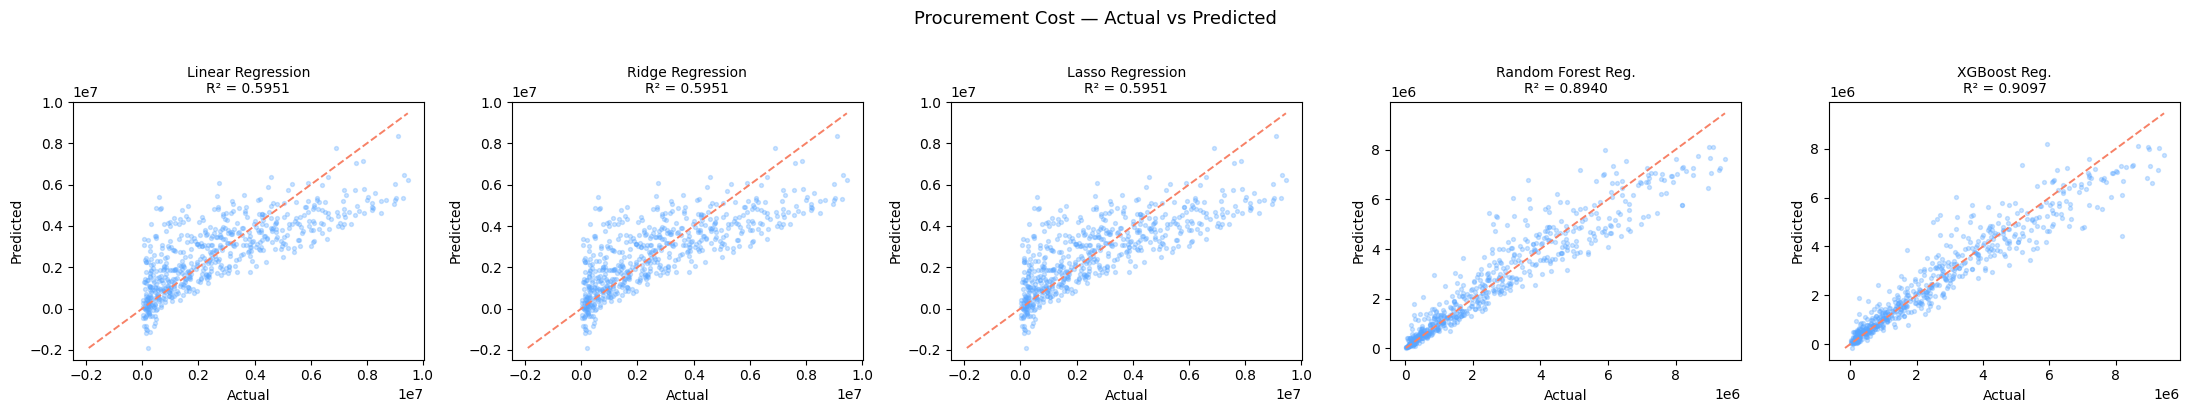

[Figure 1 - Procurement Actual vs Predicted]


In [6]:
#  2.3 Actual vs Predicted — all models  
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, y_pred) in zip(axes, proc_reg_preds.items()):
    ax.scatter(y_te, y_pred, alpha=0.3, s=8, color='#58A6FF')
    lims = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
    ax.plot(lims, lims, color='#F78166', linewidth=1.4, linestyle='--')
    r2 = r2_score(y_te, y_pred)
    ax.set_title(f'{name}\nR² = {r2:.4f}', fontsize=10)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')

plt.suptitle('Procurement Cost — Actual vs Predicted', y=1.02,
             fontsize=13, color='black')
plt.tight_layout()
plt.show()
print('[Figure 1 - Procurement Actual vs Predicted]')


**Figure: Procurement Cost Actual versus Predicted Scatter Plots**

Each of the five panels shows actual versus predicted total procurement cost for one model. Points lying close to the red dashed 45-degree reference line indicate accurate predictions. Systematic deviation above or below the line reveals directional bias, while scatter spread quantifies prediction variance. The R-squared value annotated on each panel summarises overall explained variance.

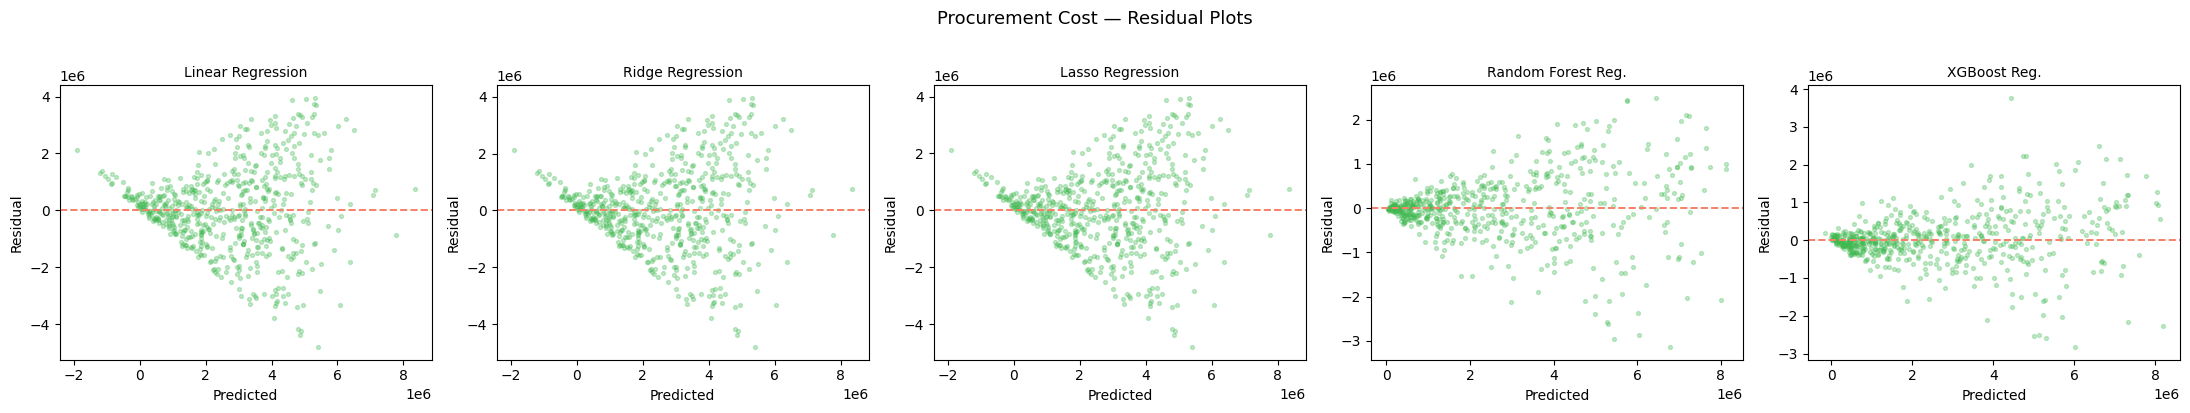

[Figure 2 - Procurement Residual Plots]


In [7]:
#  2.4 Residual plots   
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, y_pred) in zip(axes, proc_reg_preds.items()):
    residuals = y_te.values - y_pred
    ax.scatter(y_pred, residuals, alpha=0.3, s=8, color='#3FB950')
    ax.axhline(0, color='#F78166', linewidth=1.4, linestyle='--')
    ax.set_title(f'{name}', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual')

plt.suptitle('Procurement Cost — Residual Plots', y=1.02,
             fontsize=13, color='black')
plt.tight_layout()
plt.show()
print('[Figure 2 - Procurement Residual Plots]')


**Figure: Procurement Cost Residual Plots**

Each panel plots model residuals (actual minus predicted) against predicted values for one model. A random horizontal scatter around the zero line (red dashed) indicates a well-fitted model with homogeneous variance. Funnel-shaped patterns indicate heteroscedasticity, and curves indicate non-linearity that the model has failed to capture.

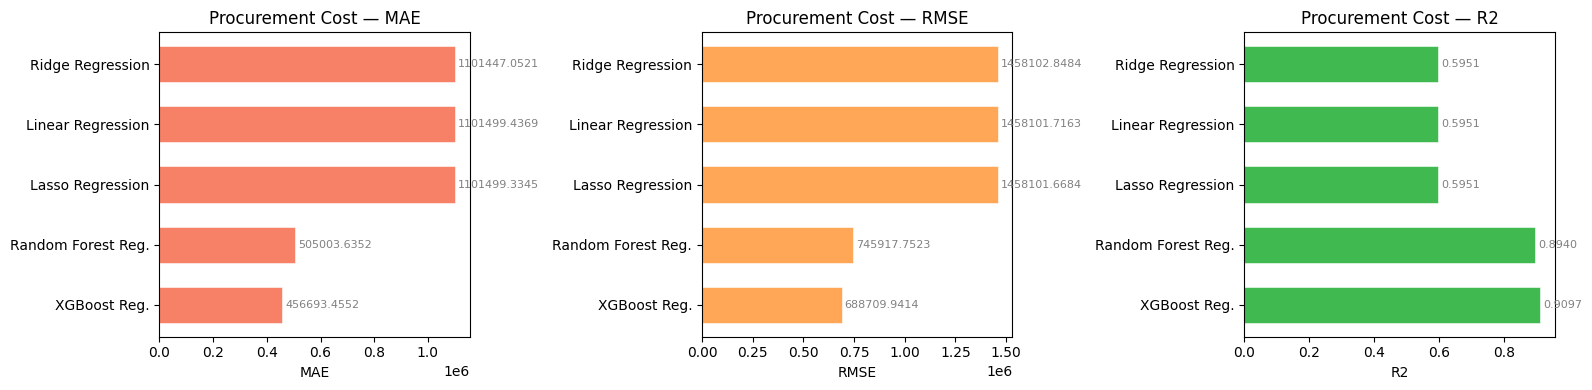

[Figure 3 - Procurement Regression Metrics Comparison]


In [8]:
#  2.5 Metrics comparison bar chart   
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

metrics = ['MAE', 'RMSE', 'R2']
colors  = ['#F78166', '#FFA657', '#3FB950']

for ax, metric, color in zip(axes, metrics, colors):
    vals   = proc_reg_df[metric]
    models = proc_reg_df['Model']
    bars = ax.barh(models, vals, color=color,
                   edgecolor='white', linewidth=0.4, height=0.6)
    for bar, val in zip(bars, vals):
        ax.text(val + abs(vals.max()) * 0.01,
                bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8, color='gray')
    ax.set_title(f'Procurement Cost — {metric}')
    ax.set_xlabel(metric)

plt.tight_layout()
plt.show()
print('[Figure 3 - Procurement Regression Metrics Comparison]')


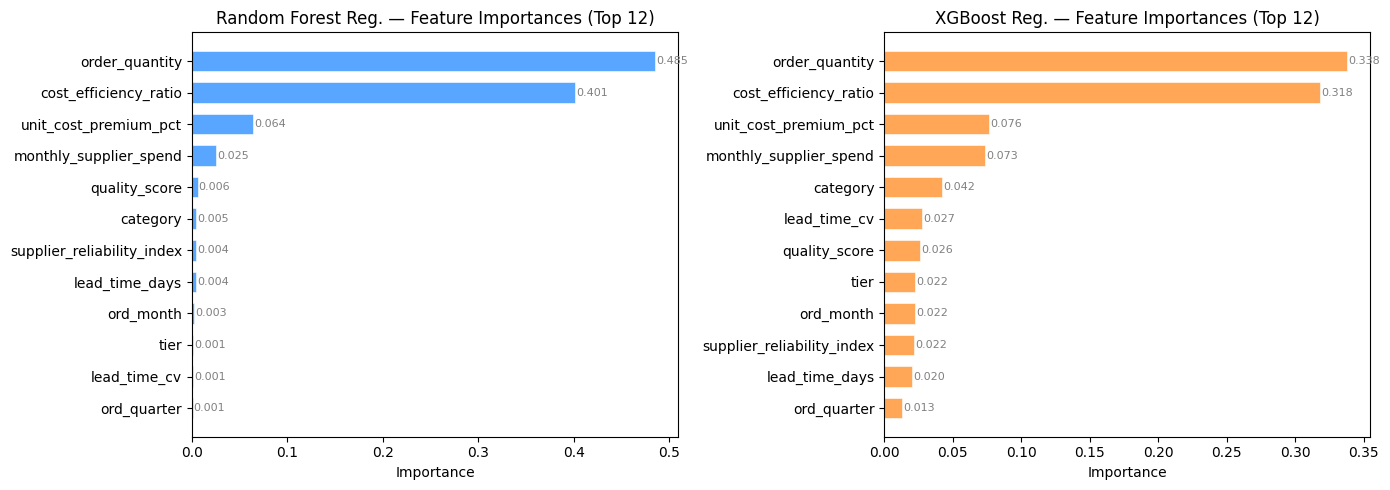

[Figure 4 - Procurement Feature Importances]


In [9]:
#  2.6 Feature importance — RF & XGBoost  
feat_names = X_proc.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model), color in zip(
        axes,
        proc_fi_models.items(),
        ['#58A6FF', '#FFA657']):
    importances = pd.Series(model.feature_importances_, index=feat_names)\
                    .sort_values(ascending=True).tail(12)
    bars = ax.barh(importances.index, importances.values,
                   color=color, edgecolor='white', linewidth=0.4, height=0.65)
    for bar, val in zip(bars, importances.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8, color='gray')
    ax.set_title(f'{name} — Feature Importances (Top 12)')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()
print('[Figure 4 - Procurement Feature Importances]')


---
## 3. Regression — Profit Margin Prediction
**Target:** `profit_margin_pct`  
**Models:** Linear Regression, Ridge, Lasso, Random Forest Regressor, XGBoost

In [10]:
#  3.1 Prepare data   
TARGET_SALES = 'profit_margin_pct'
X_sales = sales_df.drop(columns=[TARGET_SALES]).select_dtypes(include=[np.number]).copy()
y_sales = sales_df[TARGET_SALES].copy()

X_sales_imp    = SimpleImputer(strategy='median').fit_transform(X_sales)
X_sales_scaled = StandardScaler().fit_transform(X_sales_imp)

Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
    X_sales_scaled, y_sales, test_size=0.2, random_state=42
)

print(f'Train: {Xs_tr.shape}  |  Test: {Xs_te.shape}')
print(f'Target range: {y_sales.min():.2f} — {y_sales.max():.2f}  |  Mean: {y_sales.mean():.2f}')


Train: (2400, 12)  |  Test: (600, 12)
Target range: 12.32 — 59.99  |  Mean: 39.47


In [11]:
#  3.2 Train all regression models   
sales_reg_models = {
    'Linear Regression'  : LinearRegression(),
    'Ridge Regression'   : Ridge(alpha=1.0),
    'Lasso Regression'   : Lasso(alpha=0.01, max_iter=5000),
    'Random Forest Reg.' : RandomForestRegressor(n_estimators=200, max_depth=10,
                                                  min_samples_leaf=5, random_state=42,
                                                  n_jobs=-1),
    'XGBoost Reg.'       : XGBRegressor(n_estimators=300, learning_rate=0.05,
                                         max_depth=6, subsample=0.8,
                                         colsample_bytree=0.8,
                                         random_state=42, verbosity=0),
}

sales_reg_results = []
sales_reg_preds   = {}
sales_fi_models   = {}

print('=== Profit Margin Regression Results ===')
for name, model in sales_reg_models.items():
    model.fit(Xs_tr, ys_tr)
    y_pred = model.predict(Xs_te)
    sales_reg_preds[name] = y_pred
    res = eval_regression(name, ys_te, y_pred)
    sales_reg_results.append(res)
    if hasattr(model, 'feature_importances_'):
        sales_fi_models[name] = model

sales_reg_df = pd.DataFrame(sales_reg_results).sort_values('R2', ascending=False)


=== Profit Margin Regression Results ===
  Linear Regression                    MAE =     10.15  RMSE =     11.69  R2 = 0.0036
  Ridge Regression                     MAE =     10.15  RMSE =     11.69  R2 = 0.0037
  Lasso Regression                     MAE =     10.14  RMSE =     11.69  R2 = 0.0046
  Random Forest Reg.                   MAE =     10.22  RMSE =     11.83  R2 = -0.0203
  XGBoost Reg.                         MAE =     10.56  RMSE =     12.44  R2 = -0.1271


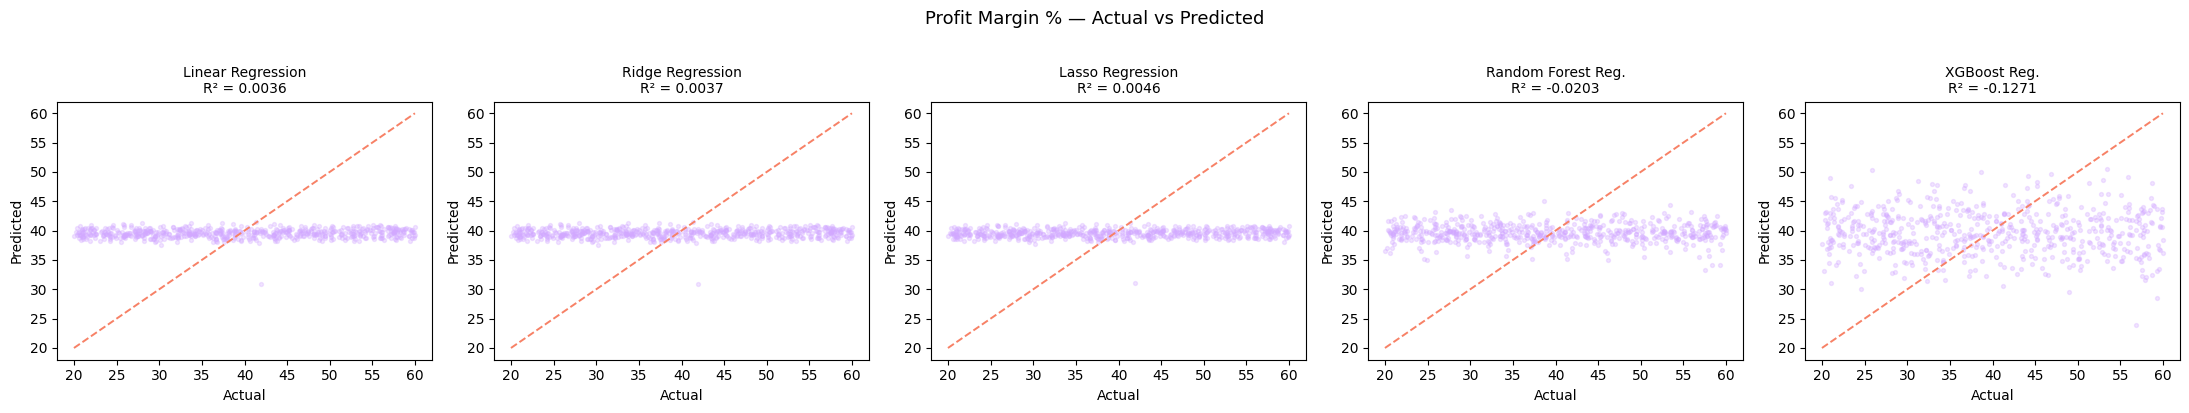

[Figure 5 - Profit Margin Actual vs Predicted]


In [12]:
#  3.3 Actual vs Predicted — all models  
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, y_pred) in zip(axes, sales_reg_preds.items()):
    ax.scatter(ys_te, y_pred, alpha=0.3, s=8, color='#D2A8FF')
    lims = [min(ys_te.min(), y_pred.min()), max(ys_te.max(), y_pred.max())]
    ax.plot(lims, lims, color='#F78166', linewidth=1.4, linestyle='--')
    r2 = r2_score(ys_te, y_pred)
    ax.set_title(f'{name}\nR² = {r2:.4f}', fontsize=10)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')

plt.suptitle('Profit Margin % — Actual vs Predicted', y=1.02,
             fontsize=13, color='black')
plt.tight_layout()
plt.show()
print('[Figure 5 - Profit Margin Actual vs Predicted]')


**Figure: Profit Margin Actual versus Predicted Scatter Plots**

The five panels show actual versus predicted profit margin percentage for each regression model. As with the procurement plots, the red dashed line represents perfect prediction. Tighter clustering around this line indicates better model fit. Models with systematically low predictions for high-margin orders may be underweighting discount or channel variables.

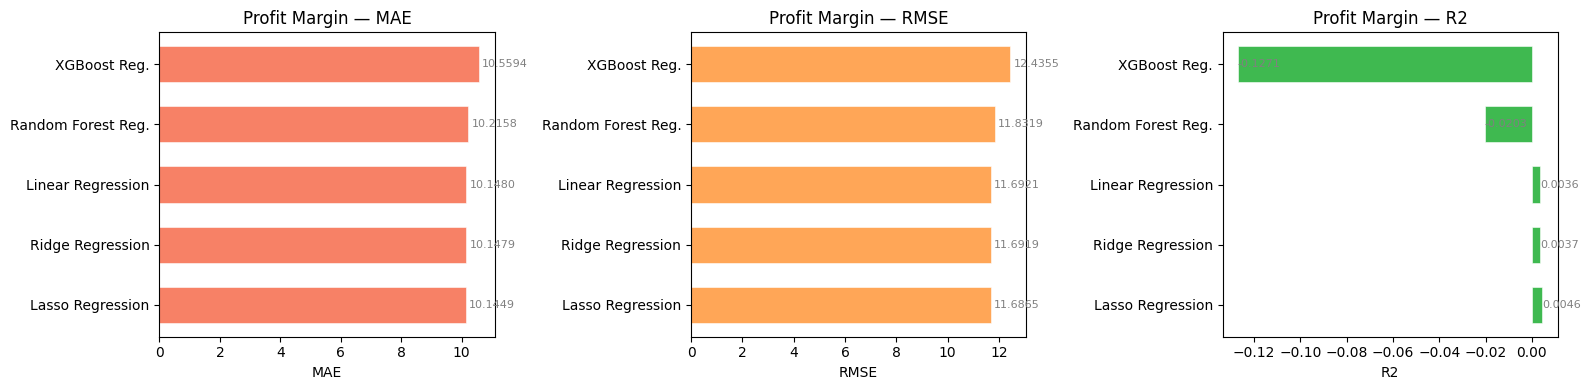

[Figure 6 - Profit Margin Regression Metrics Comparison]


In [13]:
#  3.4 Metrics comparison   
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric, color in zip(axes, ['MAE','RMSE','R2'],
                               ['#F78166','#FFA657','#3FB950']):
    vals   = sales_reg_df[metric]
    models = sales_reg_df['Model']
    bars   = ax.barh(models, vals, color=color,
                     edgecolor='white', linewidth=0.4, height=0.6)
    for bar, val in zip(bars, vals):
        ax.text(val + abs(vals.max()) * 0.01,
                bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8, color='gray')
    ax.set_title(f'Profit Margin — {metric}')
    ax.set_xlabel(metric)

plt.tight_layout()
plt.show()
print('[Figure 6 - Profit Margin Regression Metrics Comparison]')


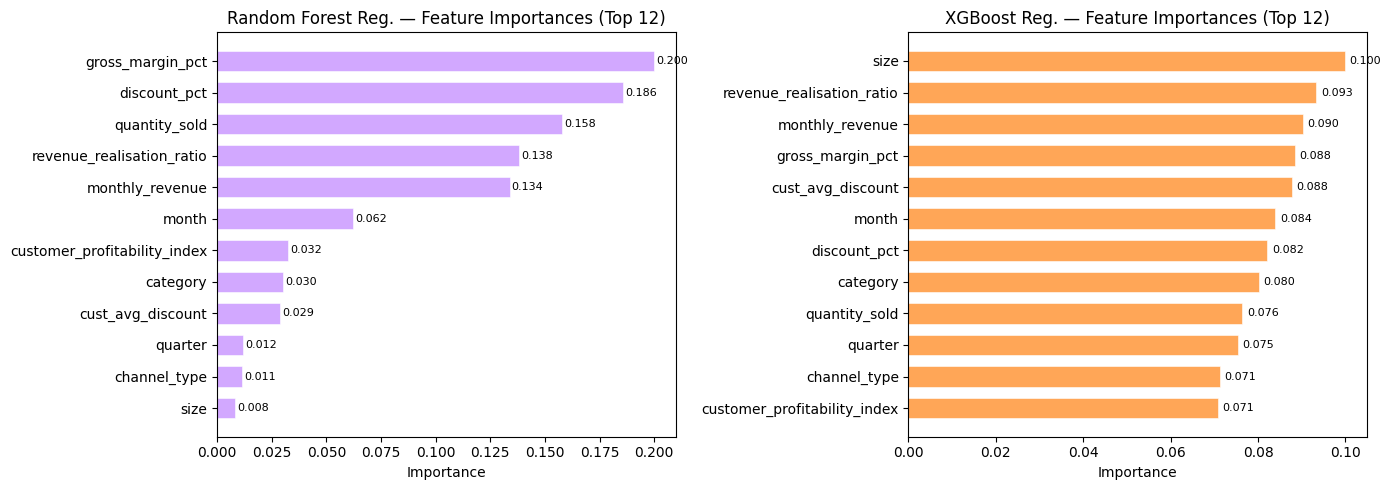

[Figure 7 - Profit Margin Feature Importances]


In [30]:
#  3.5 Feature importance — RF & XGBoost  
sales_feat_names = X_sales.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model), color in zip(
        axes, sales_fi_models.items(), ['#D2A8FF','#FFA657']):
    importances = pd.Series(model.feature_importances_, index=sales_feat_names)\
                    .sort_values(ascending=True).tail(12)
    bars = ax.barh(importances.index, importances.values,
                   color=color, edgecolor='white', linewidth=0.4, height=0.65)
    for bar, val in zip(bars, importances.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8, color='black')
    ax.set_title(f'{name} — Feature Importances (Top 12)')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()
print('[Figure 7 - Profit Margin Feature Importances]')


---
## 4. Classification — Shipment Delay Prediction
**Target:** `is_delayed`  
**Models:** Logistic Regression, Random Forest Classifier, Gradient Boosting Classifier

In [15]:
#  4.1 Prepare data   
TARGET_SHIP = 'is_delayed'
X_ship = ship_df.drop(columns=[TARGET_SHIP]).select_dtypes(include=[np.number]).copy()
y_ship = ship_df[TARGET_SHIP].copy()

X_ship_imp    = SimpleImputer(strategy='median').fit_transform(X_ship)
X_ship_scaled = StandardScaler().fit_transform(X_ship_imp)

Xsh_tr, Xsh_te, ysh_tr, ysh_te = train_test_split(
    X_ship_scaled, y_ship, test_size=0.2, random_state=42, stratify=y_ship
)

print(f'Train: {Xsh_tr.shape}  |  Test: {Xsh_te.shape}')
print(f'Class distribution (train): {pd.Series(ysh_tr).value_counts().to_dict()}')


Train: (9600, 16)  |  Test: (2400, 16)
Class distribution (train): {0: 6389, 1: 3211}


In [16]:
#  4.2 Train all classification models   
ship_cls_models = {
    'Logistic Regression'         : LogisticRegression(max_iter=1000, C=1.0,
                                                        solver='lbfgs', random_state=42),
    'Random Forest Clf.'          : RandomForestClassifier(n_estimators=200, max_depth=10,
                                                            min_samples_leaf=5,
                                                            random_state=42, n_jobs=-1),
    'Gradient Boosting Clf.'      : GradientBoostingClassifier(n_estimators=200,
                                                                 learning_rate=0.05,
                                                                 max_depth=5,
                                                                 random_state=42),
}

ship_cls_results = []
ship_cls_preds   = {}
ship_cls_probs   = {}
ship_fi_models   = {}

print('=== Shipment Delay Classification Results ===')
for name, model in ship_cls_models.items():
    model.fit(Xsh_tr, ysh_tr)
    y_pred = model.predict(Xsh_te)
    y_prob = model.predict_proba(Xsh_te)[:, 1]
    ship_cls_preds[name] = y_pred
    ship_cls_probs[name] = y_prob
    res = eval_classification(name, ysh_te, y_pred, y_prob)
    ship_cls_results.append(res)
    if hasattr(model, 'feature_importances_'):
        ship_fi_models[name] = model

ship_cls_df = pd.DataFrame(ship_cls_results).sort_values('F1', ascending=False)


=== Shipment Delay Classification Results ===
  Logistic Regression                     Acc = 0.6654  Prec = 0.0000  Rec = 0.0000  F1 = 0.0000  AUC = 0.5089
  Random Forest Clf.                      Acc = 0.6650  Prec = 0.0000  Rec = 0.0000  F1 = 0.0000  AUC = 0.5040
  Gradient Boosting Clf.                  Acc = 0.6596  Prec = 0.3600  Rec = 0.0224  F1 = 0.0422  AUC = 0.5091


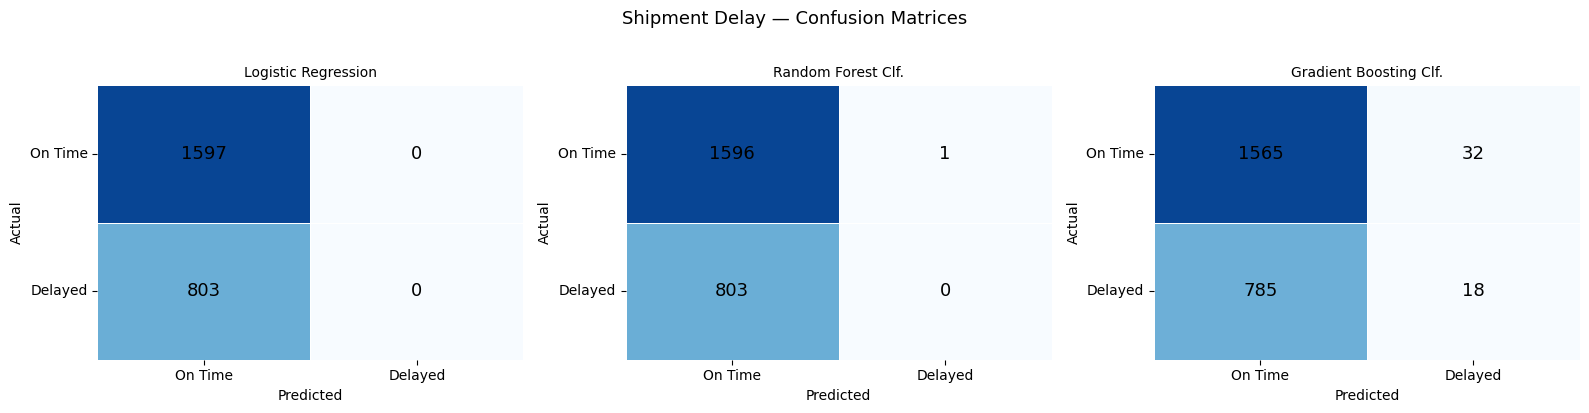

[Figure 8 - Shipment Delay Confusion Matrices]


In [17]:
#  4.3 Confusion matrices   
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, y_pred) in zip(axes, ship_cls_preds.items()):
    cm = confusion_matrix(ysh_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=CMAP_LIGHT,
                ax=ax, linewidths=0.5, linecolor='white',
                annot_kws={'size': 13, 'color': 'black'},
                cbar=False)
    ax.set_title(f'{name}', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticklabels(['On Time','Delayed'])
    ax.set_yticklabels(['On Time','Delayed'], rotation=0)

plt.suptitle('Shipment Delay — Confusion Matrices', y=1.02,
             fontsize=13, color='black')
plt.tight_layout()
plt.show()
print('[Figure 8 - Shipment Delay Confusion Matrices]')


**Figure: Shipment Delay Classification Confusion Matrices**

Each confusion matrix shows the count of true positives, true negatives, false positives, and false negatives for one classifier. In a logistics delay context, false negatives (predicting on-time when the shipment was actually delayed) are more costly than false positives, since they prevent proactive customer communication. A good model minimises false negatives without excessive false positives.

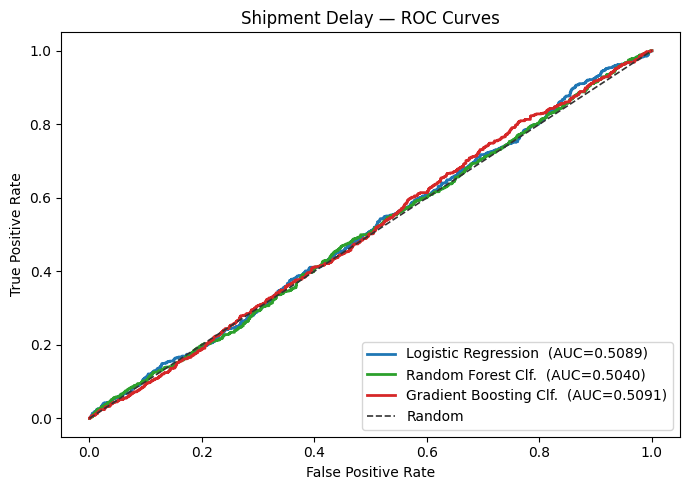

[Figure 9 - Shipment Delay ROC Curves]


In [18]:
#  4.4 ROC Curves   
fig, ax = plt.subplots(figsize=(7, 5))

for (name, y_prob), color in zip(ship_cls_probs.items(), LIGHT_PALETTE):
    fpr, tpr, _ = roc_curve(ysh_te, y_prob)
    auc = roc_auc_score(ysh_te, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name}  (AUC={auc:.4f})')

ax.plot([0,1],[0,1], color='#333333', linewidth=1.2, linestyle='--', label='Random')
ax.set_title('Shipment Delay — ROC Curves')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()
print('[Figure 9 - Shipment Delay ROC Curves]')


**Figure: Shipment Delay ROC Curves**

The Receiver Operating Characteristic (ROC) curve for each classifier plots True Positive Rate against False Positive Rate at varying classification thresholds. The Area Under the Curve (AUC) is annotated in the legend. AUC values approaching 1.0 indicate excellent discriminative ability. The dashed diagonal represents a random classifier (AUC = 0.5).

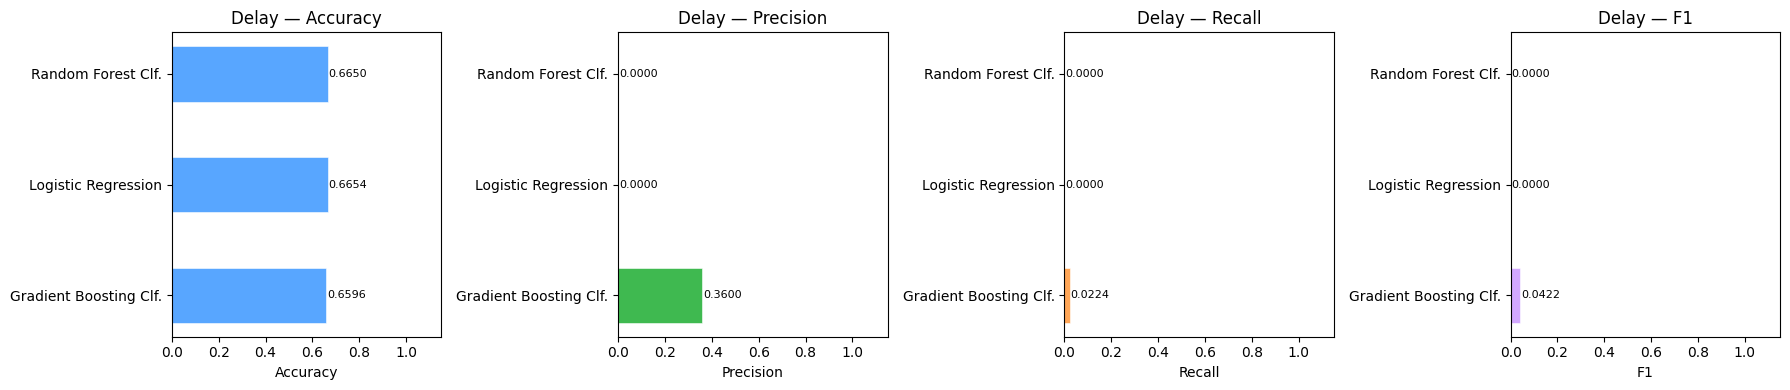

[Figure 10 - Shipment Classification Metrics Comparison]


In [31]:
#  4.5 Classification metrics bar chart  
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, metric, color in zip(
        axes,
        ['Accuracy','Precision','Recall','F1'],
        ['#58A6FF','#3FB950','#FFA657','#D2A8FF']):
    vals   = ship_cls_df[metric]
    models = ship_cls_df['Model']
    bars   = ax.barh(models, vals, color=color,
                     edgecolor='white', linewidth=0.4, height=0.5)
    for bar, val in zip(bars, vals):
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8, color='black')
    ax.set_title(f'Delay — {metric}')
    ax.set_xlabel(metric)
    ax.set_xlim(0, 1.15)

plt.tight_layout()
plt.show()
print('[Figure 10 - Shipment Classification Metrics Comparison]')


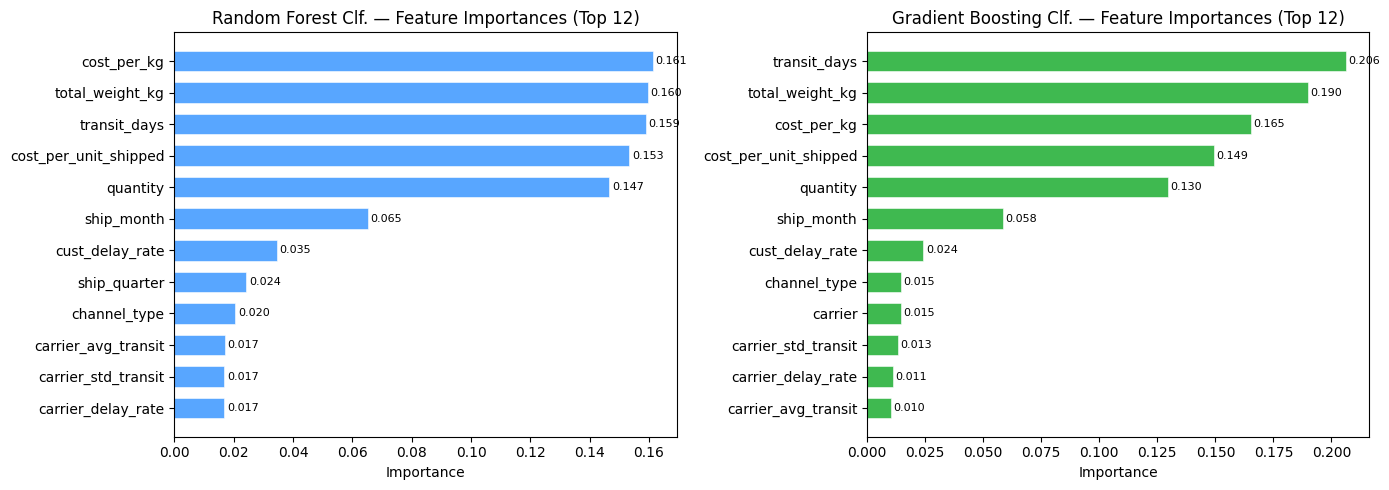

[Figure 11 - Shipment Delay Feature Importances]


In [32]:
#  4.6 Feature importance — RF & GB   
ship_feat_names = X_ship.columns.tolist()

fig, axes = plt.subplots(1, len(ship_fi_models), figsize=(7*len(ship_fi_models), 5),
)
if len(ship_fi_models) == 1:
    axes = [axes]

for ax, (name, model), color in zip(axes, ship_fi_models.items(),
                                     ['#58A6FF','#3FB950']):
    importances = pd.Series(model.feature_importances_, index=ship_feat_names)\
                    .sort_values(ascending=True).tail(12)
    bars = ax.barh(importances.index, importances.values,
                   color=color, edgecolor='white', linewidth=0.4, height=0.65)
    for bar, val in zip(bars, importances.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8, color='black')
    ax.set_title(f'{name} — Feature Importances (Top 12)')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()
print('[Figure 11 - Shipment Delay Feature Importances]')


**Figure: Shipment Delay Feature Importances**

The most influential features for predicting shipment delays are ranked by importance score from the Random Forest or Gradient Boosting model. Route delay rate, carrier reliability metrics, and transit deviation features are expected to dominate. This ranking guides operational improvement efforts by identifying which controllable factors most strongly predict late deliveries.

---
## 5. Classification — Production Defect Prediction
**Target:** `high_defect_flag` (defect_rate_pct > 5%)  
**Models:** Logistic Regression, Random Forest Classifier, Gradient Boosting Classifier

In [33]:
#  5.1 Prepare data   
TARGET_PROD = 'high_defect_flag'

defect_features = [
    'quantity_produced','defective_units','defect_rate_pct',
    'production_yield_ratio','facility_capacity_util',
    'facility_defect_rolling_avg','defect_trend',
    'defect_deviation_from_product_avg','facility_avg_yield',
    'is_weekend','month','quarter'
]

# Keep only columns that exist in prod_df
defect_features = [c for c in defect_features if c in prod_df.columns]

# Build high_defect_flag if not already present
if TARGET_PROD not in prod_df.columns:
    prod_df[TARGET_PROD] = (prod_df['defect_rate_pct'] > 5).astype(int)

defect_df = prod_df[defect_features + [TARGET_PROD]].dropna().copy()

X_prod = defect_df.drop(columns=[TARGET_PROD]).select_dtypes(include=[np.number])
y_prod = defect_df[TARGET_PROD]

X_prod_imp    = SimpleImputer(strategy='median').fit_transform(X_prod)
X_prod_scaled = StandardScaler().fit_transform(X_prod_imp)

Xp_tr, Xp_te, yp_tr, yp_te = train_test_split(
    X_prod_scaled, y_prod, test_size=0.2, random_state=42, stratify=y_prod
)

print(f'Train: {Xp_tr.shape}  |  Test: {Xp_te.shape}')
print(f'Class distribution (train): {pd.Series(yp_tr).value_counts().to_dict()}')


Train: (7200, 11)  |  Test: (1800, 11)
Class distribution (train): {0: 5432, 1: 1768}


In [34]:
#  5.2 Train all classification models   
prod_cls_models = {
    'Logistic Regression'     : LogisticRegression(max_iter=1000, C=1.0,
                                                    solver='lbfgs', random_state=42),
    'Random Forest Clf.'      : RandomForestClassifier(n_estimators=200, max_depth=10,
                                                        min_samples_leaf=5,
                                                        random_state=42, n_jobs=-1),
    'Gradient Boosting Clf.'  : GradientBoostingClassifier(n_estimators=200,
                                                             learning_rate=0.05,
                                                             max_depth=5,
                                                             random_state=42),
}

prod_cls_results = []
prod_cls_preds   = {}
prod_cls_probs   = {}
prod_fi_models   = {}

print('=== Production Defect Classification Results ===')
for name, model in prod_cls_models.items():
    model.fit(Xp_tr, yp_tr)
    y_pred = model.predict(Xp_te)
    y_prob = model.predict_proba(Xp_te)[:, 1]
    prod_cls_preds[name] = y_pred
    prod_cls_probs[name] = y_prob
    res = eval_classification(name, yp_te, y_pred, y_prob)
    prod_cls_results.append(res)
    if hasattr(model, 'feature_importances_'):
        prod_fi_models[name] = model

prod_cls_df = pd.DataFrame(prod_cls_results).sort_values('F1', ascending=False)


=== Production Defect Classification Results ===
  Logistic Regression                     Acc = 0.9928  Prec = 0.9931  Rec = 0.9774  F1 = 0.9852  AUC = 0.9998
  Random Forest Clf.                      Acc = 1.0000  Prec = 1.0000  Rec = 1.0000  F1 = 1.0000  AUC = 1.0000
  Gradient Boosting Clf.                  Acc = 1.0000  Prec = 1.0000  Rec = 1.0000  F1 = 1.0000  AUC = 1.0000


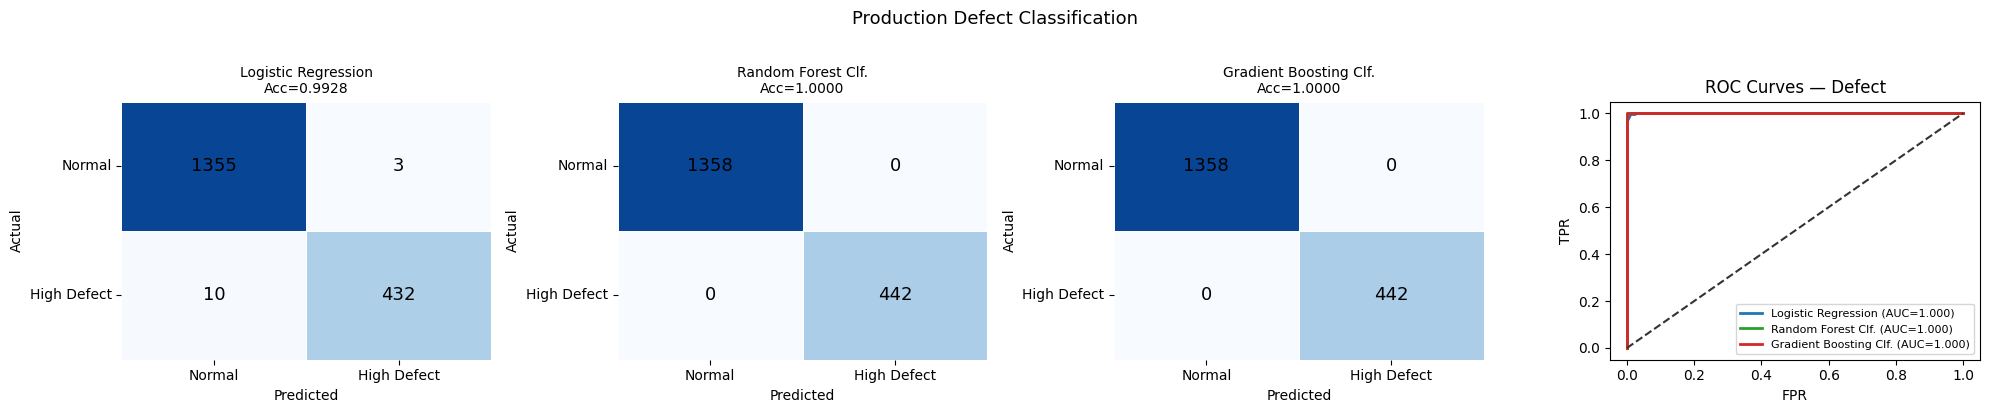

[Figure 12 - Defect Classification Results]


In [35]:
#  5.3 Confusion matrices + ROC  
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, y_pred) in zip(axes[:3], prod_cls_preds.items()):
    cm = confusion_matrix(yp_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=CMAP_LIGHT,
                ax=ax, linewidths=0.5, linecolor='white',
                annot_kws={'size': 13, 'color': 'black'}, cbar=False)
    acc = accuracy_score(yp_te, y_pred)
    ax.set_title(f'{name}\nAcc={acc:.4f}', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticklabels(['Normal','High Defect'])
    ax.set_yticklabels(['Normal','High Defect'], rotation=0)

# ROC curves in 4th panel
for (name, y_prob), color in zip(prod_cls_probs.items(), LIGHT_PALETTE):
    fpr, tpr, _ = roc_curve(yp_te, y_prob)
    auc = roc_auc_score(yp_te, y_prob)
    axes[3].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.3f})')
axes[3].plot([0,1],[0,1], color='#333333', linestyle='--')
axes[3].set_title('ROC Curves — Defect')
axes[3].set_xlabel('FPR')
axes[3].set_ylabel('TPR')
axes[3].legend(fontsize=8)

plt.suptitle('Production Defect Classification', y=1.02,
             fontsize=13, color='black')
plt.tight_layout()
plt.show()
print('[Figure 12 - Defect Classification Results]')


**Figure: Production Defect Classification — Confusion Matrices and ROC Curves**

The first three panels show confusion matrices for each defect classifier, annotated with accuracy scores. The fourth panel overlays ROC curves for all three models on a single axes with AUC values in the legend. For defect detection, high recall on the High Defect class is critical — missing a high-defect batch (false negative) allows defective units to reach customers or downstream processes.

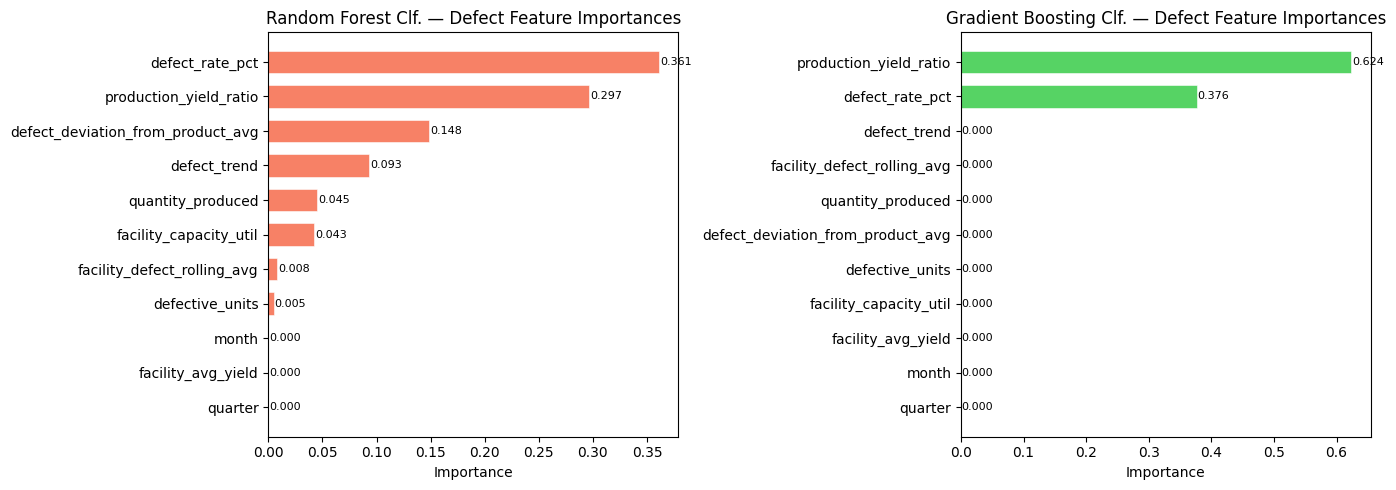

[Figure 13 - Defect Feature Importances]


In [36]:
#  5.4 Defect feature importances  
prod_feat_names = X_prod.columns.tolist()

fig, axes = plt.subplots(1, len(prod_fi_models),
                          figsize=(7*len(prod_fi_models), 5))
if len(prod_fi_models) == 1:
    axes = [axes]

for ax, (name, model), color in zip(axes, prod_fi_models.items(),
                                     ['#F78166','#56D364']):
    importances = pd.Series(model.feature_importances_, index=prod_feat_names)\
                    .sort_values(ascending=True)
    bars = ax.barh(importances.index, importances.values,
                   color=color, edgecolor='white', linewidth=0.4, height=0.65)
    for bar, val in zip(bars, importances.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8, color='black')
    ax.set_title(f'{name} — Defect Feature Importances')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()
print('[Figure 13 - Defect Feature Importances]')


**Figure: Production Defect Feature Importances**

The ranked feature importances for the defect classification task show which production variables most strongly predict high defect events. Facility-level rolling defect averages, capacity utilisation, and yield ratios are expected to rank highly. Features specific to this task that differ from the shipment delay importances confirm domain-specific defect drivers distinct from logistics factors.

---
## 6. Clustering — Supplier Segmentation
**Techniques:** K-Means, Hierarchical Clustering

In [37]:
#  6.1 Prepare supplier data  
sup_numeric_cols = [
    'total_orders','total_procurement_spend','avg_lead_time','std_lead_time',
    'avg_quality_score_proc','avg_reliability_index',
    'late_delivery_rate','avg_cost_efficiency','supplier_risk_score'
]
sup_numeric_cols = [c for c in sup_numeric_cols if c in sup_df.columns]

sup_clean = sup_df[sup_numeric_cols].dropna().copy()
sup_ids   = sup_df.loc[sup_clean.index, 'supplier_id'].values \
            if 'supplier_id' in sup_df.columns else np.arange(len(sup_clean))

sup_imp    = SimpleImputer(strategy='median').fit_transform(sup_clean)
sup_scaled = StandardScaler().fit_transform(sup_imp)



print(f'Supplier clustering data: {sup_scaled.shape}')


Supplier clustering data: (10, 9)


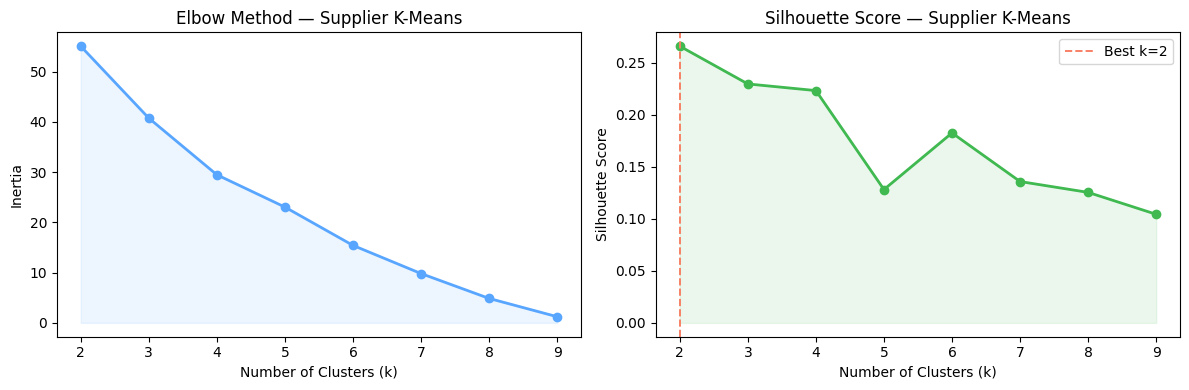

[Figure 14 - Supplier Elbow & Silhouette]   Optimal K = 2


In [38]:
#  6.2 Elbow method — optimal K   
inertias    = []
sil_scores  = []
K_range     = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(sup_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(sup_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, marker='o', color='#58A6FF',
             linewidth=2, markersize=6)
axes[0].fill_between(list(K_range), inertias, alpha=0.1, color='#58A6FF')
axes[0].set_title('Elbow Method — Supplier K-Means')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), sil_scores, marker='o', color='#3FB950',
             linewidth=2, markersize=6)
axes[1].fill_between(list(K_range), sil_scores, alpha=0.1, color='#3FB950')
axes[1].set_title('Silhouette Score — Supplier K-Means')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

BEST_K_SUP = int(np.argmax(sil_scores)) + 2
axes[1].axvline(BEST_K_SUP, color='#F78166', linestyle='--', linewidth=1.4,
                label=f'Best k={BEST_K_SUP}')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'[Figure 14 - Supplier Elbow & Silhouette]   Optimal K = {BEST_K_SUP}')


**Figure: Supplier Clustering — Elbow Method and Silhouette Score**

The left chart (Elbow Method) plots within-cluster inertia against the number of clusters. The elbow point where the inertia curve bends indicates a natural cluster boundary. The right chart plots silhouette score, which measures how well-separated clusters are. The red dashed line marks the optimal K chosen by the highest silhouette score. These two charts together justify the selected number of supplier segments.

In [39]:
#  6.3 K-Means clustering   
km_sup = KMeans(n_clusters=BEST_K_SUP, random_state=42, n_init=10)
sup_km_labels = km_sup.fit_predict(sup_scaled)

sup_result = sup_clean.copy()
sup_result['kmeans_cluster'] = sup_km_labels

sil_km = silhouette_score(sup_scaled, sup_km_labels)
print(f'K-Means Silhouette Score (k={BEST_K_SUP}): {sil_km:.4f}')

# Cluster profile
print('\nCluster Profiles (mean values):')
print(sup_result.groupby('kmeans_cluster').mean().round(3).to_string())


K-Means Silhouette Score (k=2): 0.2659

Cluster Profiles (mean values):
                total_orders  total_procurement_spend  avg_lead_time  std_lead_time  avg_quality_score_proc  avg_reliability_index  late_delivery_rate  avg_cost_efficiency  supplier_risk_score
kmeans_cluster                                                                                                                                                                                  
0                     305.50             8.012644e+08          30.25         16.674                  85.280                  0.142               0.499                1.826                0.592
1                     291.75             7.464723e+08          31.80         15.981                  85.175                  0.742               0.513                1.645                0.479


In [40]:
#  6.4 Hierarchical clustering   
hc_sup = AgglomerativeClustering(n_clusters=BEST_K_SUP, linkage='ward')
sup_hc_labels = hc_sup.fit_predict(sup_scaled)

sil_hc = silhouette_score(sup_scaled, sup_hc_labels)
print(f'Hierarchical Silhouette Score (k={BEST_K_SUP}): {sil_hc:.4f}')


Hierarchical Silhouette Score (k=2): 0.2659


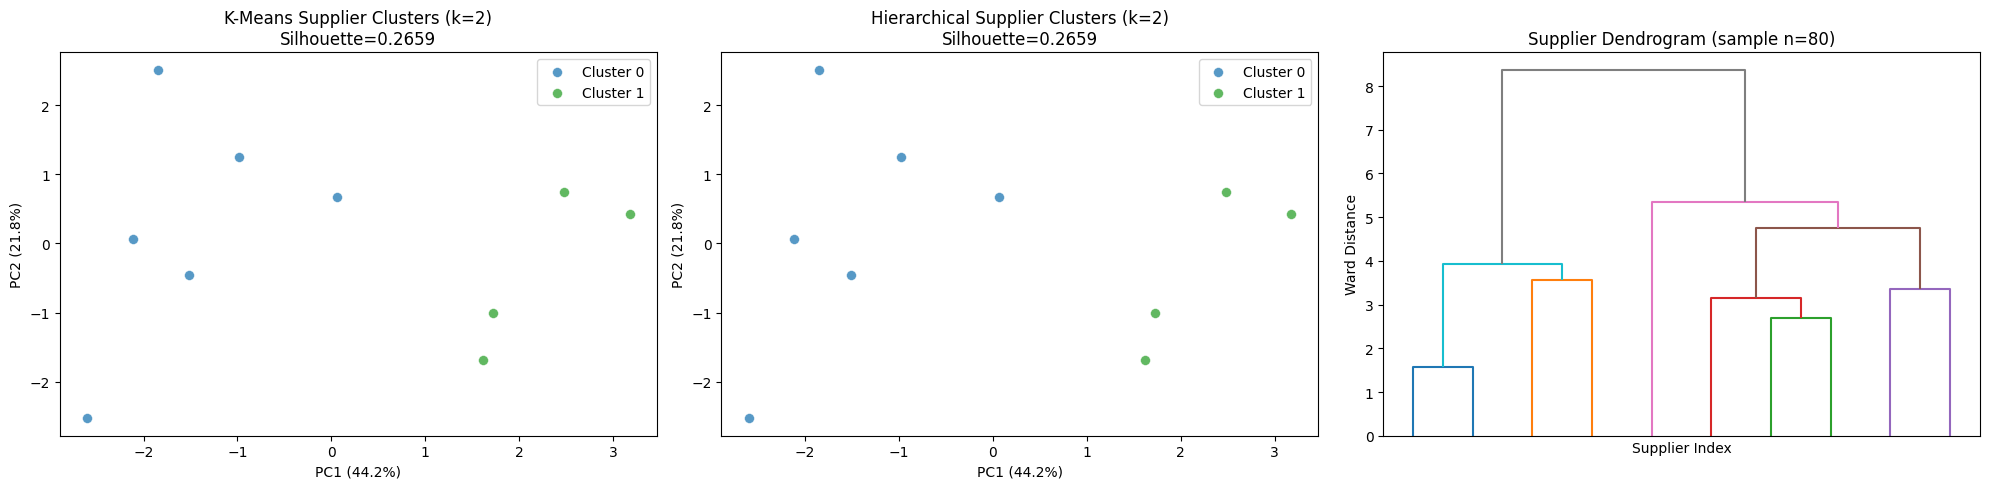

[Figure 15 - Supplier Clustering Results]


In [41]:
#  6.5 PCA scatter + Dendrogram   
pca = PCA(n_components=2, random_state=42)
sup_pca = pca.fit_transform(sup_scaled)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# K-Means PCA scatter
for k in range(BEST_K_SUP):
    mask = sup_km_labels == k
    axes[0].scatter(sup_pca[mask, 0], sup_pca[mask, 1],
                    color=LIGHT_PALETTE[k % len(LIGHT_PALETTE)],
                    label=f'Cluster {k}', alpha=0.75, s=50, edgecolors='white',
                    linewidths=0.4)
axes[0].set_title(f'K-Means Supplier Clusters (k={BEST_K_SUP})\nSilhouette={sil_km:.4f}')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()

# Hierarchical PCA scatter
for k in range(BEST_K_SUP):
    mask = sup_hc_labels == k
    axes[1].scatter(sup_pca[mask, 0], sup_pca[mask, 1],
                    color=LIGHT_PALETTE[k % len(LIGHT_PALETTE)],
                    label=f'Cluster {k}', alpha=0.75, s=50, edgecolors='white',
                    linewidths=0.4)
axes[1].set_title(f'Hierarchical Supplier Clusters (k={BEST_K_SUP})\nSilhouette={sil_hc:.4f}')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend()

# Dendrogram
sample_idx = np.random.choice(len(sup_scaled), min(80, len(sup_scaled)), replace=False)
Z = linkage(sup_scaled[sample_idx], method='ward')
dendrogram(Z, ax=axes[2], color_threshold=0,
           above_threshold_color='#333333',
           link_color_func=lambda k: LIGHT_PALETTE[k % len(LIGHT_PALETTE)])
axes[2].set_title('Supplier Dendrogram (sample n=80)')
axes[2].set_xlabel('Supplier Index')
axes[2].set_ylabel('Ward Distance')
axes[2].set_xticks([])

plt.tight_layout()
plt.show()
print('[Figure 15 - Supplier Clustering Results]')


**Figure: Supplier Clustering PCA Scatter Plots and Dendrogram**

The first two panels project supplier data onto two principal components and colour each point by its K-Means or hierarchical cluster assignment. Well-separated, compact clusters in PCA space indicate meaningful segmentation. The third panel shows a hierarchical dendrogram for a random sample, where the vertical axis represents the Ward linkage distance at which clusters merge — taller merge distances indicate more distinct groups.

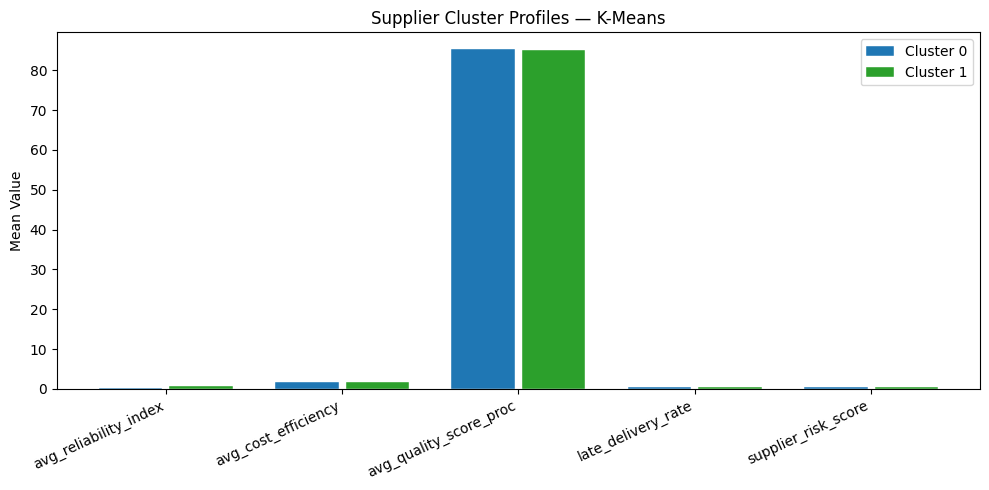

[Figure 16 - Supplier Cluster Profiles]


In [42]:
#  6.6 Cluster profile radar / bar chart  
sup_result['hc_cluster'] = sup_hc_labels

profile_cols = ['avg_reliability_index','avg_cost_efficiency',
                'avg_quality_score_proc','late_delivery_rate','supplier_risk_score']
profile_cols = [c for c in profile_cols if c in sup_result.columns]

cluster_means = sup_result.groupby('kmeans_cluster')[profile_cols].mean()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(profile_cols))
width = 0.8 / BEST_K_SUP

for i, (cluster, row) in enumerate(cluster_means.iterrows()):
    offset = (i - BEST_K_SUP/2 + 0.5) * width
    bars = ax.bar(x + offset, row.values, width * 0.9,
                  color=LIGHT_PALETTE[i % len(LIGHT_PALETTE)],
                  edgecolor='white', linewidth=0.3,
                  label=f'Cluster {cluster}')

ax.set_xticks(x)
ax.set_xticklabels(profile_cols, rotation=25, ha='right')
ax.set_title('Supplier Cluster Profiles — K-Means')
ax.set_ylabel('Mean Value')
ax.legend()

plt.tight_layout()
plt.show()
print('[Figure 16 - Supplier Cluster Profiles]')


**Figure: Supplier Cluster Profile Bar Chart (K-Means)**

Each group of bars represents a supplier cluster's mean value across key profiling dimensions: reliability index, cost efficiency, quality score, late delivery rate, and risk score. This chart gives each cluster a business interpretation (e.g. Cluster 0 = high-risk low-reliability, Cluster 1 = strategic partners), which is essential for translating clustering results into actionable sourcing decisions.

---
## 7. Clustering — Customer Segmentation
**Techniques:** K-Means, Hierarchical Clustering

In [43]:
#  7.1 Prepare customer data  
cust_numeric_cols = [
    'total_orders','total_revenue','avg_profit_margin','avg_discount_pct',
    'rfm_score','customer_ltv','cust_delay_rate',
    'product_diversity_index','revenue_cov'
]
cust_numeric_cols = [c for c in cust_numeric_cols if c in cust_df.columns]

cust_clean = cust_df[cust_numeric_cols].dropna().copy()

cust_imp    = SimpleImputer(strategy='median').fit_transform(cust_clean)
cust_scaled = StandardScaler().fit_transform(cust_imp)

print(f'Customer clustering data: {cust_scaled.shape}')


Customer clustering data: (5, 9)


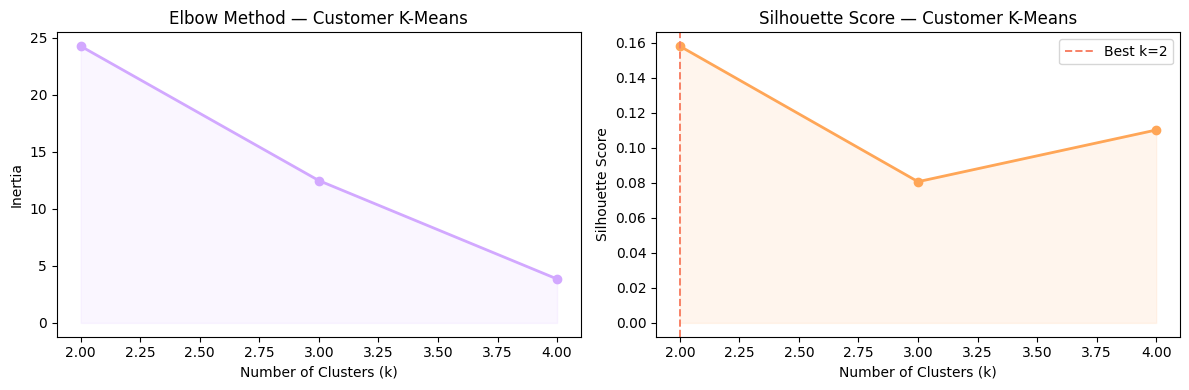

[Figure 17 - Customer Elbow & Silhouette]   Optimal K = 2


In [44]:
#  7.2 Elbow + Silhouette   
c_inertias   = []
c_sil_scores = []
K_range     = range(2, 5)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(cust_scaled)
    c_inertias.append(km.inertia_)
    c_sil_scores.append(silhouette_score(cust_scaled, labels))

BEST_K_CUST = int(np.argmax(c_sil_scores)) + 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), c_inertias, marker='o', color='#D2A8FF',
             linewidth=2, markersize=6)
axes[0].fill_between(list(K_range), c_inertias, alpha=0.1, color='#D2A8FF')
axes[0].set_title('Elbow Method — Customer K-Means')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), c_sil_scores, marker='o', color='#FFA657',
             linewidth=2, markersize=6)
axes[1].fill_between(list(K_range), c_sil_scores, alpha=0.1, color='#FFA657')
axes[1].axvline(BEST_K_CUST, color='#F78166', linestyle='--', linewidth=1.4,
                label=f'Best k={BEST_K_CUST}')
axes[1].set_title('Silhouette Score — Customer K-Means')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'[Figure 17 - Customer Elbow & Silhouette]   Optimal K = {BEST_K_CUST}')


**Figure: Customer Clustering — Elbow Method and Silhouette Score**

The same two-panel structure as the supplier clustering selection charts, but applied to customer data. The optimal number of customer segments (K) is selected based on the silhouette score maximum. Customer segmentation drives differentiated service levels, pricing tiers, and marketing resource allocation.

In [45]:
#  7.3 K-Means + Hierarchical   
km_cust = KMeans(n_clusters=BEST_K_CUST, random_state=42, n_init=10)
cust_km_labels = km_cust.fit_predict(cust_scaled)

hc_cust = AgglomerativeClustering(n_clusters=BEST_K_CUST, linkage='ward')
cust_hc_labels = hc_cust.fit_predict(cust_scaled)

sil_km_c = silhouette_score(cust_scaled, cust_km_labels)
sil_hc_c = silhouette_score(cust_scaled, cust_hc_labels)

print(f'K-Means Silhouette Score   (k={BEST_K_CUST}): {sil_km_c:.4f}')
print(f'Hierarchical Silhouette    (k={BEST_K_CUST}): {sil_hc_c:.4f}')

cust_result = cust_clean.copy()
cust_result['kmeans_cluster'] = cust_km_labels
cust_result['hc_cluster']     = cust_hc_labels

print('\nCustomer Cluster Profiles (mean values):')
print(cust_result.groupby('kmeans_cluster').mean().round(3).to_string())


K-Means Silhouette Score   (k=2): 0.1581
Hierarchical Silhouette    (k=2): 0.1942

Customer Cluster Profiles (mean values):
                total_orders  total_revenue  avg_profit_margin  avg_discount_pct  rfm_score  customer_ltv  cust_delay_rate  product_diversity_index  revenue_cov  hc_cluster
kmeans_cluster                                                                                                                                                              
0                  29898.500   9.502732e+09             39.893              0.15        6.0  3.797935e+09            0.336                    0.001        0.861         0.5
1                  30067.667   9.580515e+09             39.811              0.15       11.0  3.825187e+09            0.334                    0.001        0.858         0.0


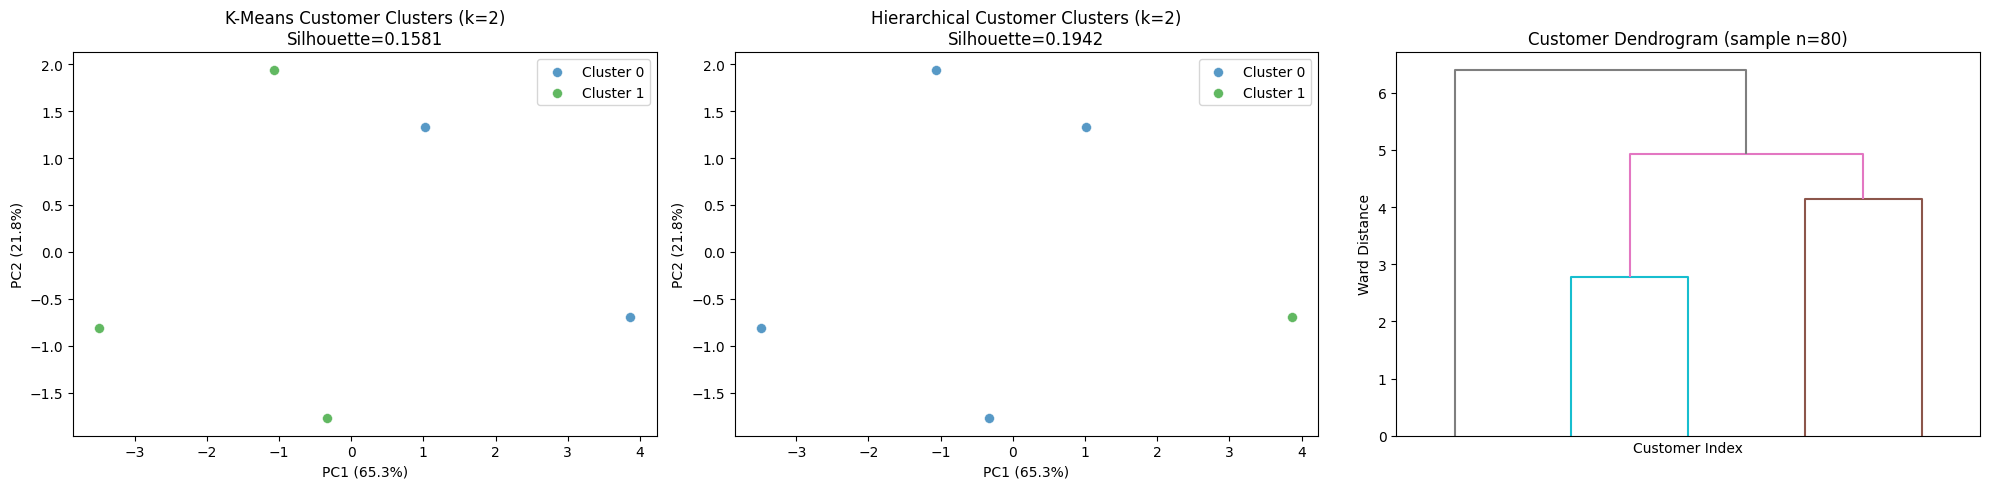

[Figure 18 - Customer Clustering Results]


In [46]:
#  7.4 PCA scatter + Dendrogram   
pca_c = PCA(n_components=2, random_state=42)
cust_pca = pca_c.fit_transform(cust_scaled)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# K-Means
for k in range(BEST_K_CUST):
    mask = cust_km_labels == k
    axes[0].scatter(cust_pca[mask, 0], cust_pca[mask, 1],
                    color=LIGHT_PALETTE[k % len(LIGHT_PALETTE)],
                    label=f'Cluster {k}', alpha=0.75, s=50,
                    edgecolors='white', linewidths=0.4)
axes[0].set_title(f'K-Means Customer Clusters (k={BEST_K_CUST})\nSilhouette={sil_km_c:.4f}')
axes[0].set_xlabel(f'PC1 ({pca_c.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_c.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()

# Hierarchical
for k in range(BEST_K_CUST):
    mask = cust_hc_labels == k
    axes[1].scatter(cust_pca[mask, 0], cust_pca[mask, 1],
                    color=LIGHT_PALETTE[k % len(LIGHT_PALETTE)],
                    label=f'Cluster {k}', alpha=0.75, s=50,
                    edgecolors='white', linewidths=0.4)
axes[1].set_title(f'Hierarchical Customer Clusters (k={BEST_K_CUST})\nSilhouette={sil_hc_c:.4f}')
axes[1].set_xlabel(f'PC1 ({pca_c.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_c.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend()

# Dendrogram
sample_idx = np.random.choice(len(cust_scaled), min(80, len(cust_scaled)), replace=False)
Zc = linkage(cust_scaled[sample_idx], method='ward')
dendrogram(Zc, ax=axes[2], color_threshold=0,
           above_threshold_color='#333333',
           link_color_func=lambda k: LIGHT_PALETTE[k % len(LIGHT_PALETTE)])
axes[2].set_title('Customer Dendrogram (sample n=80)')
axes[2].set_xlabel('Customer Index')
axes[2].set_ylabel('Ward Distance')
axes[2].set_xticks([])

plt.tight_layout()
plt.show()
print('[Figure 18 - Customer Clustering Results]')


**Figure: Customer Clustering PCA Scatter Plots and Dendrogram**

K-Means and hierarchical customer clusters are projected onto two principal components derived from customer-level RFM and behavioural features. The dendrogram provides a complementary hierarchical view of customer similarity. Tight, well-separated clusters in PCA space confirm that the customer feature set has sufficient discriminative power for meaningful segmentation.

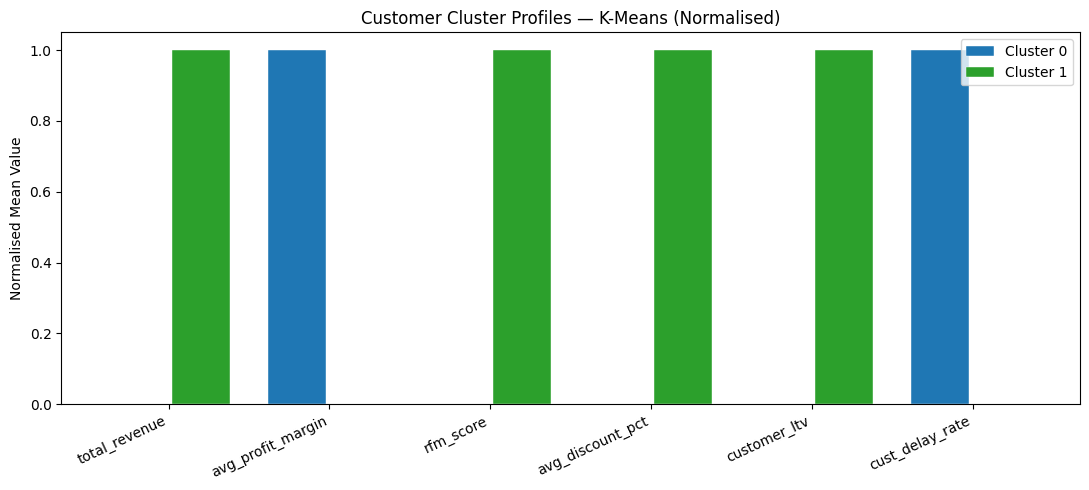

[Figure 19 - Customer Cluster Profiles]


In [47]:
#  7.5 Customer cluster profile bar chart  
cust_profile_cols = ['total_revenue','avg_profit_margin','rfm_score',
                     'avg_discount_pct','customer_ltv','cust_delay_rate']
cust_profile_cols = [c for c in cust_profile_cols if c in cust_result.columns]

cust_cluster_means = cust_result.groupby('kmeans_cluster')[cust_profile_cols].mean()

# Normalise for fair visual comparison
cust_cluster_norm = (cust_cluster_means - cust_cluster_means.min()) / \
                    (cust_cluster_means.max() - cust_cluster_means.min() + 1e-9)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(cust_profile_cols))
width = 0.8 / BEST_K_CUST

for i, (cluster, row) in enumerate(cust_cluster_norm.iterrows()):
    offset = (i - BEST_K_CUST/2 + 0.5) * width
    ax.bar(x + offset, row.values, width * 0.9,
           color=LIGHT_PALETTE[i % len(LIGHT_PALETTE)],
           edgecolor='white', linewidth=0.3,
           label=f'Cluster {cluster}')

ax.set_xticks(x)
ax.set_xticklabels(cust_profile_cols, rotation=25, ha='right')
ax.set_title('Customer Cluster Profiles — K-Means (Normalised)')
ax.set_ylabel('Normalised Mean Value')
ax.legend()

plt.tight_layout()
plt.show()
print('[Figure 19 - Customer Cluster Profiles]')


**Figure: Customer Cluster Profile Bar Chart — Normalised K-Means Profiles**

Normalised mean values for each customer cluster are compared across revenue, profit margin, RFM score, discount percentage, lifetime value, and delay rate. Normalisation allows direct visual comparison across features with different scales. Each cluster's profile shape gives it a business label such as high-value loyal, discount-seekers, or at-risk churners.

---
## 8. Model Comparison Summary

In [48]:
#  8.1 Regression summary table   
print('=' * 75)
print('  REGRESSION SUMMARY — PROCUREMENT COST')
print('=' * 75)
print(proc_reg_df[['Model','MAE','RMSE','R2']].to_string(index=False))

print()
print('=' * 75)
print('  REGRESSION SUMMARY — PROFIT MARGIN %')
print('=' * 75)
print(sales_reg_df[['Model','MAE','RMSE','R2']].to_string(index=False))


  REGRESSION SUMMARY — PROCUREMENT COST
             Model          MAE         RMSE       R2
      XGBoost Reg. 4.566935e+05 6.887099e+05 0.909673
Random Forest Reg. 5.050036e+05 7.459178e+05 0.894044
  Lasso Regression 1.101499e+06 1.458102e+06 0.595125
 Linear Regression 1.101499e+06 1.458102e+06 0.595125
  Ridge Regression 1.101447e+06 1.458103e+06 0.595124

  REGRESSION SUMMARY — PROFIT MARGIN %
             Model       MAE      RMSE        R2
  Lasso Regression 10.144910 11.686512  0.004593
  Ridge Regression 10.147878 11.691906  0.003674
 Linear Regression 10.148014 11.692091  0.003643
Random Forest Reg. 10.215788 11.831874 -0.020324
      XGBoost Reg. 10.559410 12.435474 -0.127082


In [49]:
#  8.2 Classification summary table   
print('=' * 90)
print('  CLASSIFICATION SUMMARY — SHIPMENT DELAY')
print('=' * 90)
print(ship_cls_df[['Model','Accuracy','Precision','Recall','F1','AUC']].to_string(index=False))

print()
print('=' * 90)
print('  CLASSIFICATION SUMMARY — PRODUCTION DEFECT')
print('=' * 90)
print(prod_cls_df[['Model','Accuracy','Precision','Recall','F1','AUC']].to_string(index=False))


  CLASSIFICATION SUMMARY — SHIPMENT DELAY
                 Model  Accuracy  Precision   Recall       F1      AUC
Gradient Boosting Clf.  0.659583       0.36 0.022416 0.042204 0.509090
   Logistic Regression  0.665417       0.00 0.000000 0.000000 0.508892
    Random Forest Clf.  0.665000       0.00 0.000000 0.000000 0.504037

  CLASSIFICATION SUMMARY — PRODUCTION DEFECT
                 Model  Accuracy  Precision   Recall       F1      AUC
    Random Forest Clf.  1.000000   1.000000 1.000000 1.000000 1.000000
Gradient Boosting Clf.  1.000000   1.000000 1.000000 1.000000 1.000000
   Logistic Regression  0.992778   0.993103 0.977376 0.985177 0.999785


In [50]:
#  8.3 Clustering summary   
clustering_summary = pd.DataFrame([
    {'Domain':'Supplier','Method':'K-Means',       'k':BEST_K_SUP, 'Silhouette':round(sil_km, 4)},
    {'Domain':'Supplier','Method':'Hierarchical',  'k':BEST_K_SUP, 'Silhouette':round(sil_hc, 4)},
    {'Domain':'Customer','Method':'K-Means',       'k':BEST_K_CUST,'Silhouette':round(sil_km_c, 4)},
    {'Domain':'Customer','Method':'Hierarchical',  'k':BEST_K_CUST,'Silhouette':round(sil_hc_c, 4)},
])
print('=' * 55)
print('  CLUSTERING SUMMARY')
print('=' * 55)
print(clustering_summary.to_string(index=False))


  CLUSTERING SUMMARY
  Domain       Method  k  Silhouette
Supplier      K-Means  2      0.2659
Supplier Hierarchical  2      0.2659
Customer      K-Means  2      0.1581
Customer Hierarchical  2      0.1942


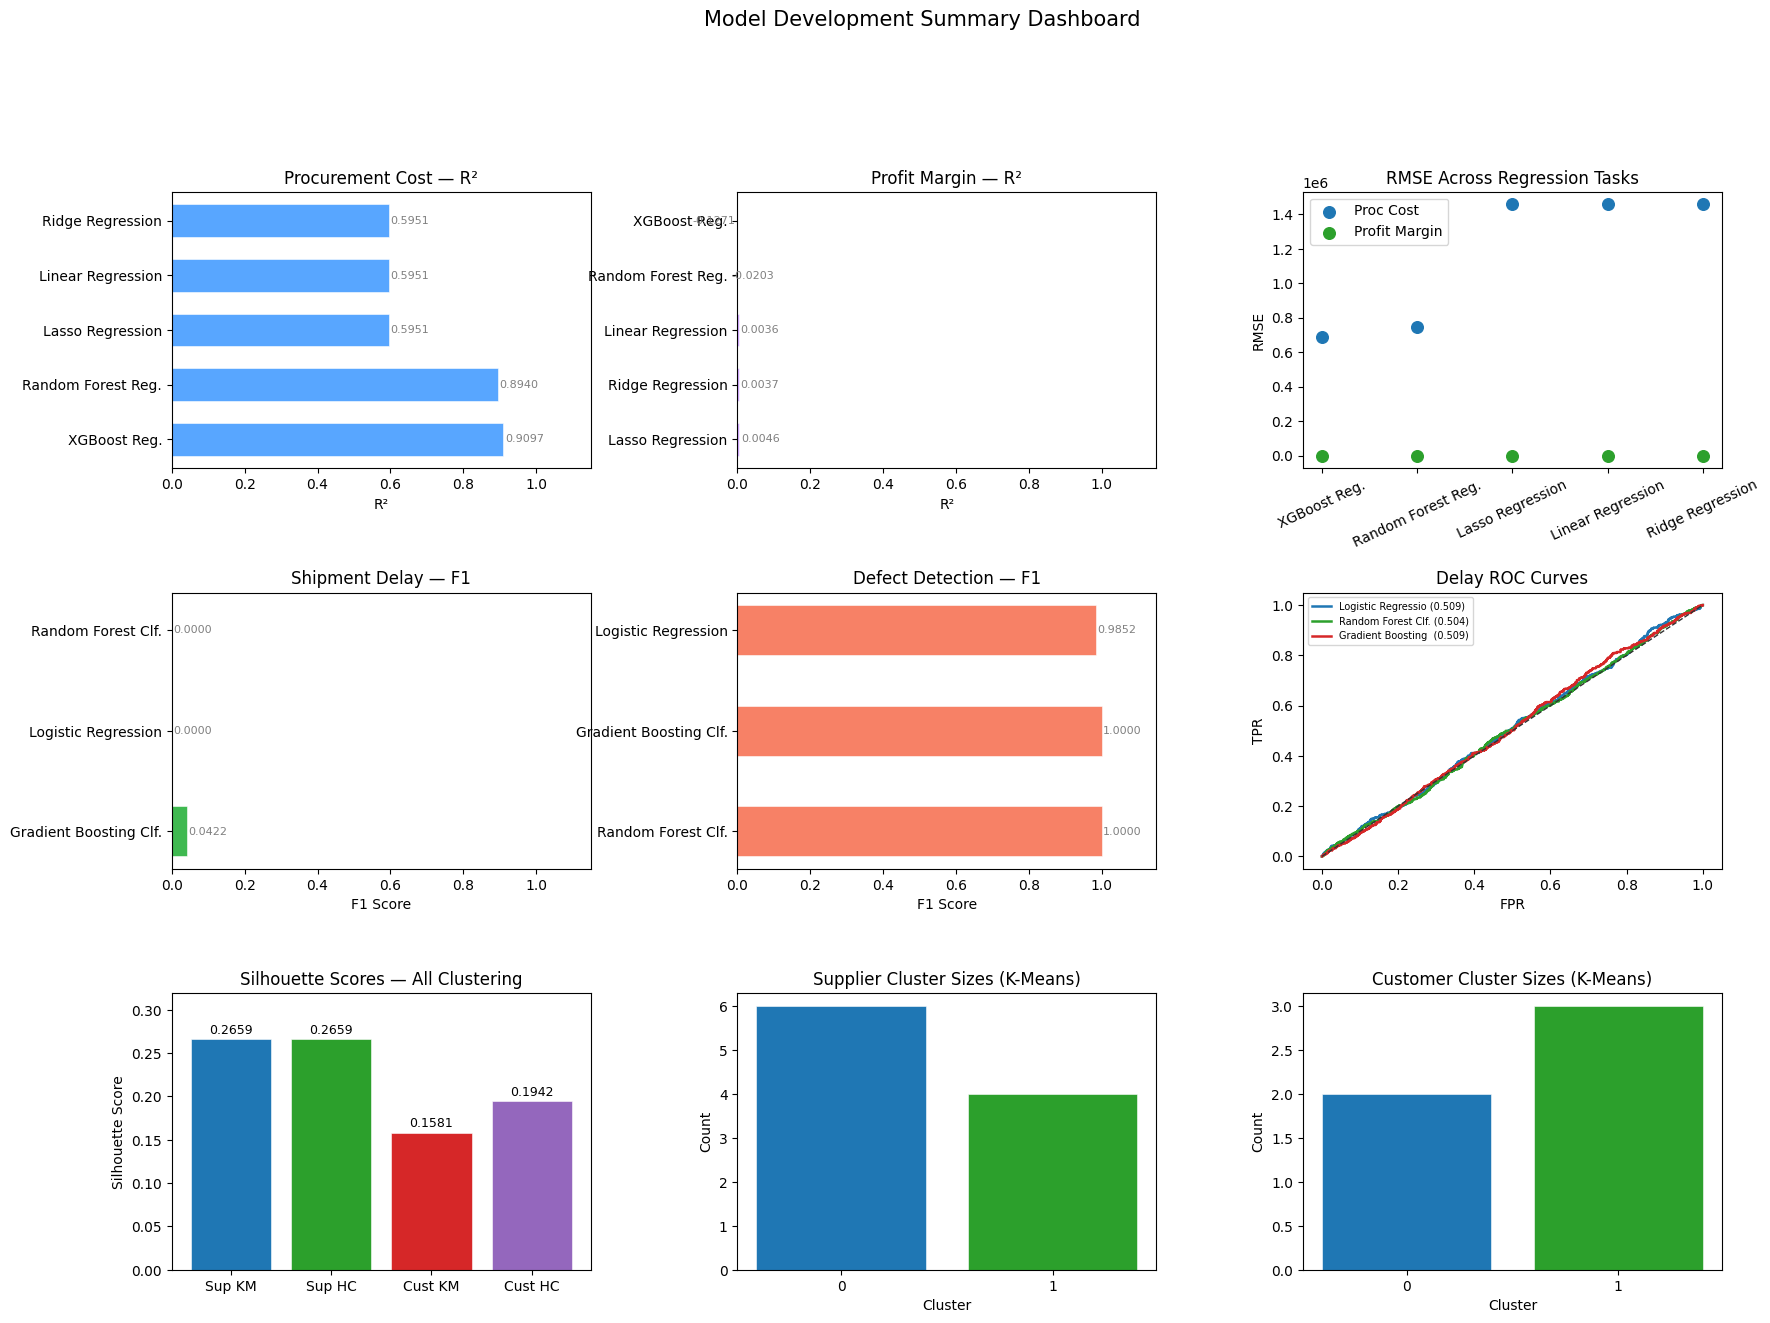

[Figure 20 - Model Summary Dashboard]


In [51]:
#  8.4 Master comparison dashboard   
fig = plt.figure(figsize=(20, 14))
gs  = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# --- Row 1: Regression R2 scores ---
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

for ax, df, title, color in [
    (ax1, proc_reg_df,  'Procurement Cost — R²',  '#58A6FF'),
    (ax2, sales_reg_df, 'Profit Margin — R²',      '#D2A8FF'),
]:
    bars = ax.barh(df['Model'], df['R2'], color=color,
                   edgecolor='white', linewidth=0.4, height=0.6)
    for bar, val in zip(bars, df['R2']):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8, color='gray')
    ax.set_title(title)
    ax.set_xlabel('R²')
    ax.set_xlim(0, 1.15)

# Regression RMSE comparison
ax3 = fig.add_subplot(gs[0, 2])
all_reg_rmse = pd.concat([
    proc_reg_df[['Model','RMSE']].assign(Target='Proc Cost'),
    sales_reg_df[['Model','RMSE']].assign(Target='Profit Margin')
])
for i, (target, grp) in enumerate(all_reg_rmse.groupby('Target')):
    ax3.scatter(grp['Model'], grp['RMSE'],
                color=LIGHT_PALETTE[i], s=70, label=target, zorder=3)
ax3.set_title('RMSE Across Regression Tasks')
ax3.set_ylabel('RMSE')
ax3.tick_params(axis='x', rotation=25)
ax3.legend()

# --- Row 2: Classification F1 scores ---
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])

for ax, df, title, color in [
    (ax4, ship_cls_df, 'Shipment Delay — F1',   '#3FB950'),
    (ax5, prod_cls_df, 'Defect Detection — F1', '#F78166'),
]:
    bars = ax.barh(df['Model'], df['F1'], color=color,
                   edgecolor='white', linewidth=0.4, height=0.5)
    for bar, val in zip(bars, df['F1']):
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8, color='gray')
    ax.set_title(title)
    ax.set_xlabel('F1 Score')
    ax.set_xlim(0, 1.15)

# AUC comparison
ax6 = fig.add_subplot(gs[1, 2])
for (name, y_prob), color in zip(ship_cls_probs.items(), LIGHT_PALETTE):
    fpr, tpr, _ = roc_curve(ysh_te, y_prob)
    auc = roc_auc_score(ysh_te, y_prob)
    ax6.plot(fpr, tpr, color=color, linewidth=1.8, label=f'{name[:18]} ({auc:.3f})')
ax6.plot([0,1],[0,1], color='#333333', linestyle='--', linewidth=1)
ax6.set_title('Delay ROC Curves')
ax6.set_xlabel('FPR')
ax6.set_ylabel('TPR')
ax6.legend(fontsize=7)

# --- Row 3: Clustering silhouette + cluster sizes ---
ax7 = fig.add_subplot(gs[2, 0])
ax8 = fig.add_subplot(gs[2, 1])
ax9 = fig.add_subplot(gs[2, 2])

# Silhouette bar chart
sil_labels = ['Sup KM','Sup HC','Cust KM','Cust HC']
sil_vals   = [sil_km, sil_hc, sil_km_c, sil_hc_c]
sil_colors = LIGHT_PALETTE[:4]
bars = ax7.bar(sil_labels, sil_vals, color=sil_colors,
               edgecolor='white', linewidth=0.4)
for bar, val in zip(bars, sil_vals):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9, color='black')
ax7.set_title('Silhouette Scores — All Clustering')
ax7.set_ylabel('Silhouette Score')
ax7.set_ylim(0, max(sil_vals) * 1.2)

# Supplier cluster sizes
sup_sizes = pd.Series(sup_km_labels).value_counts().sort_index()
ax8.bar(sup_sizes.index.astype(str), sup_sizes.values,
        color=LIGHT_PALETTE[:len(sup_sizes)],
        edgecolor='white', linewidth=0.4)
ax8.set_title('Supplier Cluster Sizes (K-Means)')
ax8.set_xlabel('Cluster')
ax8.set_ylabel('Count')

# Customer cluster sizes
cust_sizes = pd.Series(cust_km_labels).value_counts().sort_index()
ax9.bar(cust_sizes.index.astype(str), cust_sizes.values,
        color=LIGHT_PALETTE[:len(cust_sizes)],
        edgecolor='white', linewidth=0.4)
ax9.set_title('Customer Cluster Sizes (K-Means)')
ax9.set_xlabel('Cluster')
ax9.set_ylabel('Count')

fig.suptitle('Model Development Summary Dashboard',
             fontsize=15, color='black', y=1.01)

plt.show()
print('[Figure 20 - Model Summary Dashboard]')


**Figure: Model Development Summary Dashboard**

A nine-panel dashboard summarising all model development results. Row 1 compares regression R-squared values across tasks and models. Row 2 compares classification F1 scores and overlays ROC curves. Row 3 shows clustering silhouette scores and cluster size distributions for both supplier and customer segmentation. This single-page view provides a complete model selection reference.

In [52]:
#  8.5 Save all results tables   
os.makedirs('results', exist_ok=True)

proc_reg_df.to_csv('results/regression_procurement_results.csv', index=False)
sales_reg_df.to_csv('results/regression_profit_margin_results.csv', index=False)
ship_cls_df.to_csv('results/classification_shipment_delay_results.csv', index=False)
prod_cls_df.to_csv('results/classification_defect_results.csv', index=False)
clustering_summary.to_csv('results/clustering_summary.csv', index=False)

sup_result.to_csv('results/supplier_cluster_assignments.csv', index=False)
cust_result.to_csv('results/customer_cluster_assignments.csv', index=False)

print('All result tables saved to /results/')

#  Final print summary   
sep = '=' * 72
print()
print(sep)
print('MODEL DEVELOPMENT SUMMARY')
print(sep)

best_proc  = proc_reg_df.iloc[0]
best_sales = sales_reg_df.iloc[0]
best_ship  = ship_cls_df.iloc[0]
best_prod  = prod_cls_df.iloc[0]

print(f'  Best Procurement Cost Model : {best_proc["Model"]:30s}  R2={best_proc["R2"]:.4f}')
print(f'  Best Profit Margin Model    : {best_sales["Model"]:30s}  R2={best_sales["R2"]:.4f}')
print(f'  Best Delay Classifier       : {best_ship["Model"]:30s}  F1={best_ship["F1"]:.4f}')
print(f'  Best Defect Classifier      : {best_prod["Model"]:30s}  F1={best_prod["F1"]:.4f}')
print(f'  Supplier Clusters (K-Means) : k={BEST_K_SUP}  Silhouette={sil_km:.4f}')
print(f'  Customer Clusters (K-Means) : k={BEST_K_CUST}  Silhouette={sil_km_c:.4f}')
print(sep)


All result tables saved to /results/

MODEL DEVELOPMENT SUMMARY
  Best Procurement Cost Model : XGBoost Reg.                    R2=0.9097
  Best Profit Margin Model    : Lasso Regression                R2=0.0046
  Best Delay Classifier       : Gradient Boosting Clf.          F1=0.0422
  Best Defect Classifier      : Random Forest Clf.              F1=1.0000
  Supplier Clusters (K-Means) : k=2  Silhouette=0.2659
  Customer Clusters (K-Means) : k=2  Silhouette=0.1581


---
## 9. Phase 5: Model Evaluation

Each model is evaluated on the **held-out test set** using the full suite of metrics defined in the project proposal.

- Regression: MAE, RMSE, R²  
- Classification: Accuracy, Precision, Recall, F1 Score, AUC  
- Clustering: Silhouette Score  

Cross-validation scores are also reported to assess generalisation.

### 9.1 Regression Evaluation — Procurement Cost

In [53]:
#  9.1 Detailed regression evaluation — Procurement Cost  
from sklearn.model_selection import cross_val_score, KFold
import scipy.stats as stats

print('=' * 80)
print('EVALUATION — REGRESSION: PROCUREMENT COST (total_cost)')
print('=' * 80)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
proc_eval_rows = []

for name, model in proc_reg_models.items():
    y_pred = proc_reg_preds[name]

    mae   = mean_absolute_error(y_te, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_te, y_pred))
    r2    = r2_score(y_te, y_pred)
    mape  = np.mean(np.abs((y_te.values - y_pred) / (np.abs(y_te.values) + 1e-9))) * 100

    # 5-fold CV on full scaled data
    cv_r2 = cross_val_score(model, X_proc_scaled, y_proc,
                             cv=kf, scoring='r2', n_jobs=-1)

    print(f'\n  Model : {name}')
    print(f'  MAE   = {mae:>12.4f}')
    print(f'  RMSE  = {rmse:>12.4f}')
    print(f'  R²    = {r2:>12.4f}')
    print(f'  MAPE  = {mape:>12.2f}%')
    print(f'  CV R² = {cv_r2.mean():.4f} ± {cv_r2.std():.4f}  (5-fold)')
    print(f'  CV R² folds: {[round(v,4) for v in cv_r2]}')

    proc_eval_rows.append({
        'Model': name, 'MAE': round(mae,4), 'RMSE': round(rmse,4),
        'R2': round(r2,4), 'MAPE(%)': round(mape,2),
        'CV_R2_mean': round(cv_r2.mean(),4), 'CV_R2_std': round(cv_r2.std(),4)
    })

proc_eval_df = pd.DataFrame(proc_eval_rows).sort_values('R2', ascending=False)
print('\n  Summary Table:')
print(proc_eval_df.to_string(index=False))


EVALUATION — REGRESSION: PROCUREMENT COST (total_cost)

  Model : Linear Regression
  MAE   = 1101499.4369
  RMSE  = 1458101.7163
  R²    =       0.5951
  MAPE  =       146.67%
  CV R² = 0.5773 ± 0.0151  (5-fold)
  CV R² folds: [np.float64(0.5951), np.float64(0.5913), np.float64(0.5574), np.float64(0.5622), np.float64(0.5803)]

  Model : Ridge Regression
  MAE   = 1101447.0521
  RMSE  = 1458102.8484
  R²    =       0.5951
  MAPE  =       146.63%
  CV R² = 0.5773 ± 0.0151  (5-fold)
  CV R² folds: [np.float64(0.5951), np.float64(0.5913), np.float64(0.5574), np.float64(0.5623), np.float64(0.5802)]

  Model : Lasso Regression
  MAE   = 1101499.3345
  RMSE  = 1458101.6684
  R²    =       0.5951
  MAPE  =       146.67%
  CV R² = 0.5773 ± 0.0151  (5-fold)
  CV R² folds: [np.float64(0.5951), np.float64(0.5913), np.float64(0.5574), np.float64(0.5622), np.float64(0.5803)]

  Model : Random Forest Reg.
  MAE   =  505003.6352
  RMSE  =  745917.7523
  R²    =       0.8940
  MAPE  =        32.12%
  

### 9.2 Regression Evaluation — Profit Margin

In [54]:
#  9.2 Detailed regression evaluation — Profit Margin  
print('=' * 80)
print('  PHASE 5 EVALUATION — REGRESSION: PROFIT MARGIN (profit_margin_pct)')
print('=' * 80)

sales_eval_rows = []

for name, model in sales_reg_models.items():
    y_pred = sales_reg_preds[name]

    mae   = mean_absolute_error(ys_te, y_pred)
    rmse  = np.sqrt(mean_squared_error(ys_te, y_pred))
    r2    = r2_score(ys_te, y_pred)
    mape  = np.mean(np.abs((ys_te.values - y_pred) / (np.abs(ys_te.values) + 1e-9))) * 100

    cv_r2 = cross_val_score(model, X_sales_scaled, y_sales,
                             cv=kf, scoring='r2', n_jobs=-1)

    print(f'\n  Model : {name}')
    print(f'  MAE   = {mae:>12.4f}')
    print(f'  RMSE  = {rmse:>12.4f}')
    print(f'  R²    = {r2:>12.4f}')
    print(f'  MAPE  = {mape:>12.2f}%')
    print(f'  CV R² = {cv_r2.mean():.4f} ± {cv_r2.std():.4f}  (5-fold)')

    sales_eval_rows.append({
        'Model': name, 'MAE': round(mae,4), 'RMSE': round(rmse,4),
        'R2': round(r2,4), 'MAPE(%)': round(mape,2),
        'CV_R2_mean': round(cv_r2.mean(),4), 'CV_R2_std': round(cv_r2.std(),4)
    })

sales_eval_df = pd.DataFrame(sales_eval_rows).sort_values('R2', ascending=False)
print('\n  Summary Table:')
print(sales_eval_df.to_string(index=False))


  PHASE 5 EVALUATION — REGRESSION: PROFIT MARGIN (profit_margin_pct)

  Model : Linear Regression
  MAE   =      10.1480
  RMSE  =      11.6921
  R²    =       0.0036
  MAPE  =        29.44%
  CV R² = -0.0040 ± 0.0091  (5-fold)

  Model : Ridge Regression
  MAE   =      10.1479
  RMSE  =      11.6919
  R²    =       0.0037
  MAPE  =        29.43%
  CV R² = -0.0040 ± 0.0091  (5-fold)

  Model : Lasso Regression
  MAE   =      10.1449
  RMSE  =      11.6865
  R²    =       0.0046
  MAPE  =        29.42%
  CV R² = -0.0031 ± 0.0086  (5-fold)

  Model : Random Forest Reg.
  MAE   =      10.2158
  RMSE  =      11.8319
  R²    =      -0.0203
  MAPE  =        29.66%
  CV R² = -0.0215 ± 0.0130  (5-fold)

  Model : XGBoost Reg.
  MAE   =      10.5594
  RMSE  =      12.4355
  R²    =      -0.1271
  MAPE  =        30.57%
  CV R² = -0.1246 ± 0.0226  (5-fold)

  Summary Table:
             Model     MAE    RMSE      R2  MAPE(%)  CV_R2_mean  CV_R2_std
  Lasso Regression 10.1449 11.6865  0.0046    29.

### 9.3 Regression Metrics Visualisation

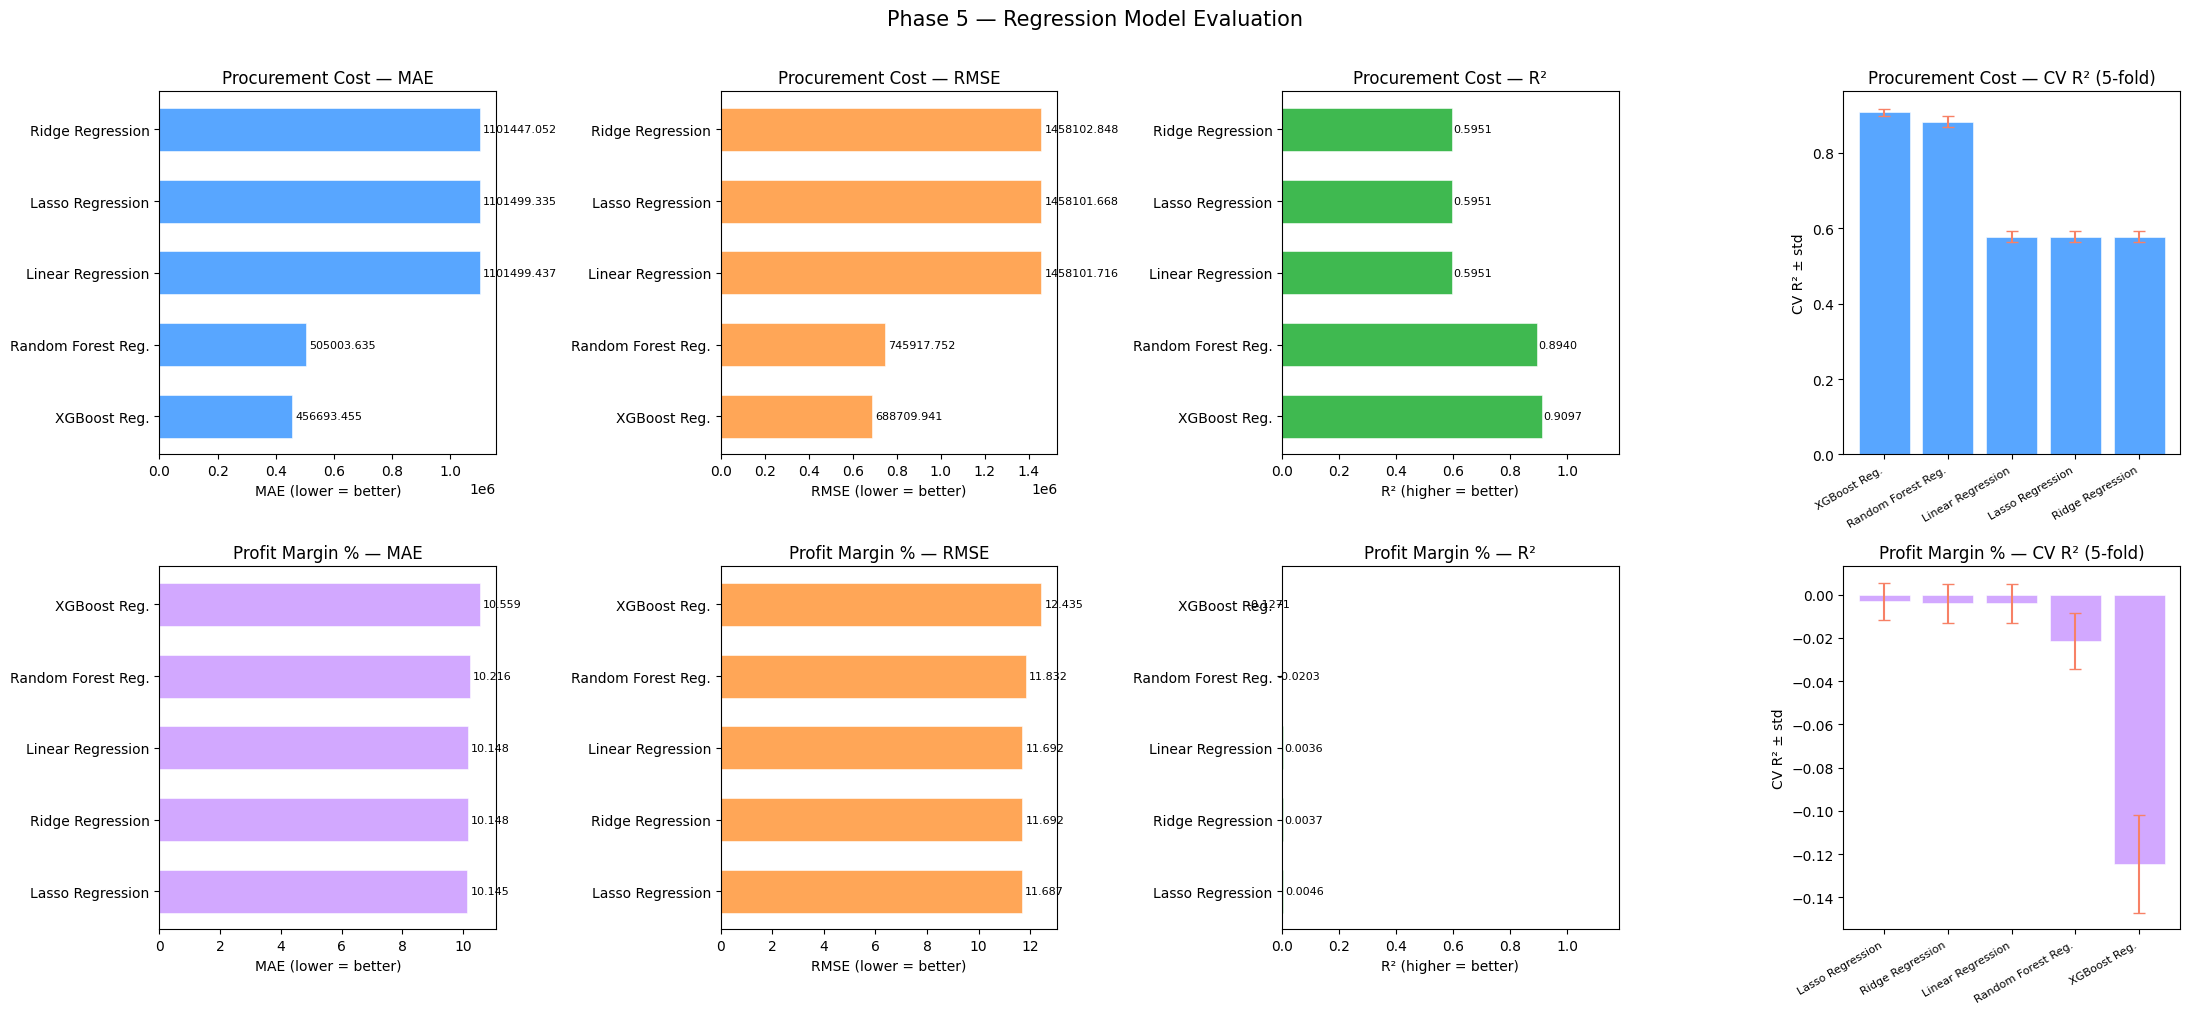

[Figure 21 - Regression Evaluation Metrics]


In [56]:
#  9.3 Regression evaluation plots  
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

tasks = [
    ('Procurement Cost', proc_eval_df,  y_te,  proc_reg_preds,  '#58A6FF'),
    ('Profit Margin %',  sales_eval_df, ys_te, sales_reg_preds, '#D2A8FF'),
]

for row_idx, (task_name, eval_df, y_true, preds_dict, color) in enumerate(tasks):
    axes_row = axes[row_idx]

    # MAE bar
    bars = axes_row[0].barh(eval_df['Model'], eval_df['MAE'],
                             color=color, edgecolor='white', linewidth=0.4, height=0.6)
    for bar, val in zip(bars, eval_df['MAE']):
        axes_row[0].text(val + eval_df['MAE'].max()*0.01,
                         bar.get_y()+bar.get_height()/2,
                         f'{val:.3f}', va='center', fontsize=8, color='black')
    axes_row[0].set_title(f'{task_name} — MAE')
    axes_row[0].set_xlabel('MAE (lower = better)')

    # RMSE bar
    bars = axes_row[1].barh(eval_df['Model'], eval_df['RMSE'],
                             color='#FFA657', edgecolor='white', linewidth=0.4, height=0.6)
    for bar, val in zip(bars, eval_df['RMSE']):
        axes_row[1].text(val + eval_df['RMSE'].max()*0.01,
                         bar.get_y()+bar.get_height()/2,
                         f'{val:.3f}', va='center', fontsize=8, color='black')
    axes_row[1].set_title(f'{task_name} — RMSE')
    axes_row[1].set_xlabel('RMSE (lower = better)')

    # R² bar
    bars = axes_row[2].barh(eval_df['Model'], eval_df['R2'],
                             color='#3FB950', edgecolor='white', linewidth=0.4, height=0.6)
    for bar, val in zip(bars, eval_df['R2']):
        axes_row[2].text(val + 0.005,
                         bar.get_y()+bar.get_height()/2,
                         f'{val:.4f}', va='center', fontsize=8, color='black')
    axes_row[2].set_title(f'{task_name} — R²')
    axes_row[2].set_xlabel('R² (higher = better)')
    axes_row[2].set_xlim(0, 1.18)

    # CV R² with error bars
    x_pos = np.arange(len(eval_df))
    axes_row[3].bar(x_pos, eval_df['CV_R2_mean'],
                    yerr=eval_df['CV_R2_std'],
                    color=color, edgecolor='white', linewidth=0.4,
                    error_kw={'ecolor':'#F78166','linewidth':1.5,'capsize':4})
    axes_row[3].set_xticks(x_pos)
    axes_row[3].set_xticklabels(eval_df['Model'], rotation=30, ha='right', fontsize=8)
    axes_row[3].set_title(f'{task_name} — CV R² (5-fold)')
    axes_row[3].set_ylabel('CV R² ± std')

plt.suptitle('Phase 5 — Regression Model Evaluation', fontsize=15,
             color='black', y=1.01)
plt.tight_layout()
plt.show()
print('[Figure 21 - Regression Evaluation Metrics]')


**Figure: Phase 5 Regression Model Evaluation — MAE, RMSE, R-squared, and Cross-Validation R-squared**

Two rows of four panels each evaluate procurement cost and profit margin regression models respectively. The first three columns compare MAE, RMSE, and R-squared on the held-out test set. The fourth column shows 5-fold cross-validation R-squared with error bars representing standard deviation across folds. Low error bar height indicates stable, generalisable models.

### 9.4 Residual Distribution Analysis

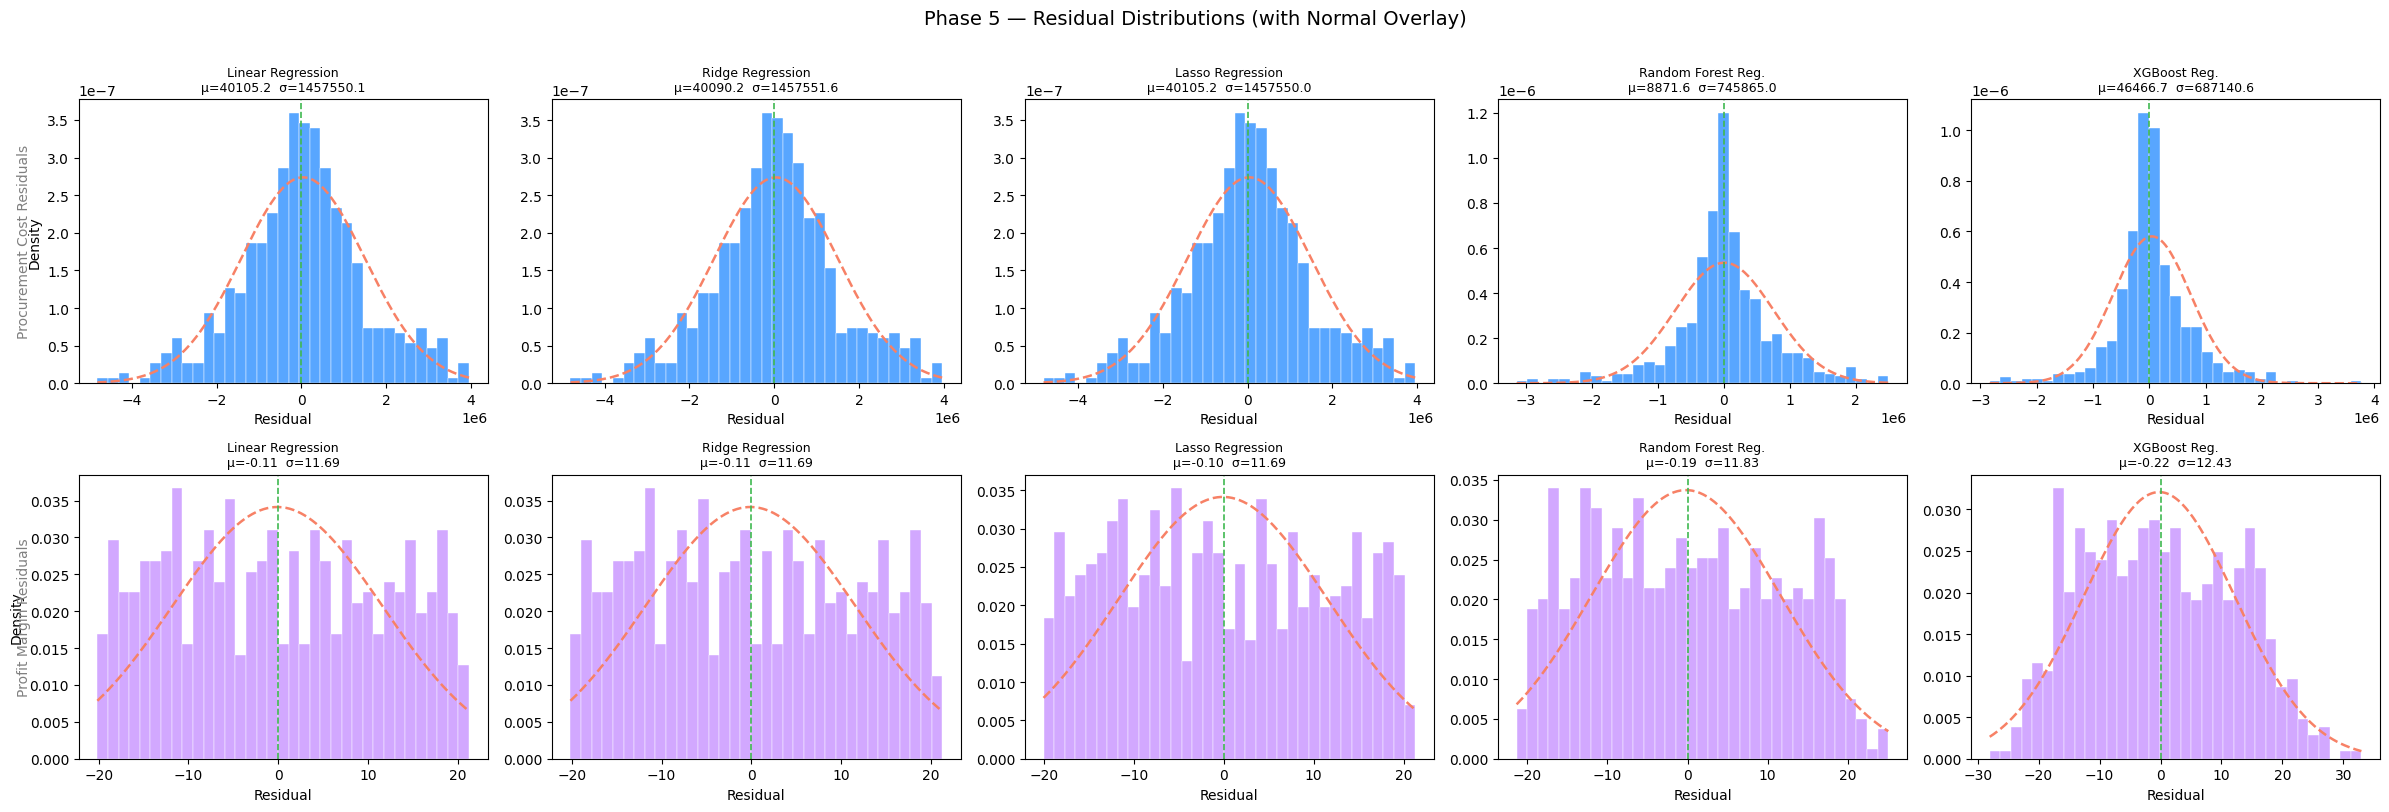

[Figure 22 - Residual Distributions]


In [57]:
#  9.4 Residual normality & distribution per model  
fig, axes = plt.subplots(2, 5, figsize=(24, 8))

for col_idx, (name, y_pred) in enumerate(proc_reg_preds.items()):
    residuals = y_te.values - y_pred
    ax = axes[0, col_idx]
    ax.hist(residuals, bins=35, color='#58A6FF', edgecolor='white', linewidth=0.3,
            density=True)
    # Overlay normal curve
    mu, sigma = residuals.mean(), residuals.std()
    x_range = np.linspace(residuals.min(), residuals.max(), 200)
    ax.plot(x_range, stats.norm.pdf(x_range, mu, sigma),
            color='#F78166', linewidth=1.8, linestyle='--')
    ax.axvline(0, color='#3FB950', linewidth=1.2, linestyle='--')
    ax.set_title(f'{name}\nμ={mu:.1f}  σ={sigma:.1f}', fontsize=9)
    ax.set_xlabel('Residual')
    ax.set_ylabel('Density' if col_idx == 0 else '')

for col_idx, (name, y_pred) in enumerate(sales_reg_preds.items()):
    residuals = ys_te.values - y_pred
    ax = axes[1, col_idx]
    ax.hist(residuals, bins=35, color='#D2A8FF', edgecolor='white', linewidth=0.3,
            density=True)
    mu, sigma = residuals.mean(), residuals.std()
    x_range = np.linspace(residuals.min(), residuals.max(), 200)
    ax.plot(x_range, stats.norm.pdf(x_range, mu, sigma),
            color='#F78166', linewidth=1.8, linestyle='--')
    ax.axvline(0, color='#3FB950', linewidth=1.2, linestyle='--')
    ax.set_title(f'{name}\nμ={mu:.2f}  σ={sigma:.2f}', fontsize=9)
    ax.set_xlabel('Residual')
    ax.set_ylabel('Density' if col_idx == 0 else '')

axes[0, 0].annotate('Procurement Cost Residuals', xy=(-0.15, 0.5),
                     xycoords='axes fraction', rotation=90,
                     va='center', fontsize=10, color='gray')
axes[1, 0].annotate('Profit Margin Residuals', xy=(-0.15, 0.5),
                     xycoords='axes fraction', rotation=90,
                     va='center', fontsize=10, color='gray')

plt.suptitle('Phase 5 — Residual Distributions (with Normal Overlay)',
             fontsize=14, color='black', y=1.01)
plt.tight_layout()
plt.show()
print('[Figure 22 - Residual Distributions]')


**Figure: Residual Distributions with Normal Overlay**

Each histogram shows the distribution of prediction residuals for one model and one task. The red dashed curve overlays a fitted normal distribution with the same mean and standard deviation. For a well-calibrated linear model, residuals should approximate a normal distribution centred at zero. Skewed or heavy-tailed residual distributions suggest systematic prediction errors that non-linear models may better address.

### 9.5 Classification Evaluation — Shipment Delay

In [58]:
#  9.5 Full classification evaluation — Shipment Delay  
from sklearn.model_selection import StratifiedKFold, cross_val_score

print('=' * 90)
print(' EVALUATION — CLASSIFICATION: SHIPMENT DELAY (is_delayed)')
print('=' * 90)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ship_eval_rows = []

for name, model in ship_cls_models.items():
    y_pred = ship_cls_preds[name]
    y_prob = ship_cls_probs[name]

    acc   = accuracy_score(ysh_te, y_pred)
    prec  = precision_score(ysh_te, y_pred, zero_division=0)
    rec   = recall_score(ysh_te, y_pred, zero_division=0)
    f1    = f1_score(ysh_te, y_pred, zero_division=0)
    auc   = roc_auc_score(ysh_te, y_prob)

    # Per-class precision / recall
    report = classification_report(ysh_te, y_pred,
                                    target_names=['On Time','Delayed'],
                                    output_dict=True, zero_division=0)

    cv_f1 = cross_val_score(model, X_ship_scaled, y_ship,
                             cv=skf, scoring='f1', n_jobs=-1)

    print(f'\n  Model : {name}')
    print(f'  Accuracy   = {acc:.4f}')
    print(f'  Precision  = {prec:.4f}   (Delayed class)')
    print(f'  Recall     = {rec:.4f}   (Delayed class)')
    print(f'  F1 Score   = {f1:.4f}')
    print(f'  AUC-ROC    = {auc:.4f}')
    print(f'  CV F1      = {cv_f1.mean():.4f} ± {cv_f1.std():.4f}  (5-fold stratified)')
    print(f'  On-Time   -> Prec={report["On Time"]["precision"]:.4f}  Rec={report["On Time"]["recall"]:.4f}  F1={report["On Time"]["f1-score"]:.4f}')
    print(f'  Delayed   -> Prec={report["Delayed"]["precision"]:.4f}  Rec={report["Delayed"]["recall"]:.4f}  F1={report["Delayed"]["f1-score"]:.4f}')

    ship_eval_rows.append({
        'Model': name,
        'Accuracy': round(acc,4), 'Precision': round(prec,4),
        'Recall': round(rec,4), 'F1': round(f1,4),
        'AUC': round(auc,4),
        'CV_F1_mean': round(cv_f1.mean(),4), 'CV_F1_std': round(cv_f1.std(),4)
    })

ship_eval_df = pd.DataFrame(ship_eval_rows).sort_values('F1', ascending=False)
print('\n  Summary Table:')
print(ship_eval_df.to_string(index=False))


 EVALUATION — CLASSIFICATION: SHIPMENT DELAY (is_delayed)

  Model : Logistic Regression
  Accuracy   = 0.6654
  Precision  = 0.0000   (Delayed class)
  Recall     = 0.0000   (Delayed class)
  F1 Score   = 0.0000
  AUC-ROC    = 0.5089
  CV F1      = 0.0000 ± 0.0000  (5-fold stratified)
  On-Time   -> Prec=0.6654  Rec=1.0000  F1=0.7991
  Delayed   -> Prec=0.0000  Rec=0.0000  F1=0.0000

  Model : Random Forest Clf.
  Accuracy   = 0.6650
  Precision  = 0.0000   (Delayed class)
  Recall     = 0.0000   (Delayed class)
  F1 Score   = 0.0000
  AUC-ROC    = 0.5040
  CV F1      = 0.0010 ± 0.0012  (5-fold stratified)
  On-Time   -> Prec=0.6653  Rec=0.9994  F1=0.7988
  Delayed   -> Prec=0.0000  Rec=0.0000  F1=0.0000

  Model : Gradient Boosting Clf.
  Accuracy   = 0.6596
  Precision  = 0.3600   (Delayed class)
  Recall     = 0.0224   (Delayed class)
  F1 Score   = 0.0422
  AUC-ROC    = 0.5091
  CV F1      = 0.0359 ± 0.0079  (5-fold stratified)
  On-Time   -> Prec=0.6660  Rec=0.9800  F1=0.7930
  D

### 9.6 Classification Evaluation — Production Defect

In [59]:
#  9.6 Full classification evaluation — Production Defect  
print('=' * 90)
print('EVALUATION — CLASSIFICATION: PRODUCTION DEFECT (high_defect_flag)')
print('=' * 90)

prod_eval_rows = []

for name, model in prod_cls_models.items():
    y_pred = prod_cls_preds[name]
    y_prob = prod_cls_probs[name]

    acc   = accuracy_score(yp_te, y_pred)
    prec  = precision_score(yp_te, y_pred, zero_division=0)
    rec   = recall_score(yp_te, y_pred, zero_division=0)
    f1    = f1_score(yp_te, y_pred, zero_division=0)
    auc   = roc_auc_score(yp_te, y_prob)

    report = classification_report(yp_te, y_pred,
                                    target_names=['Normal','High Defect'],
                                    output_dict=True, zero_division=0)

    cv_f1 = cross_val_score(model, X_prod_scaled, y_prod,
                             cv=skf, scoring='f1', n_jobs=-1)

    print(f'\n  Model : {name}')
    print(f'  Accuracy   = {acc:.4f}')
    print(f'  Precision  = {prec:.4f}   (High Defect class)')
    print(f'  Recall     = {rec:.4f}   (High Defect class)')
    print(f'  F1 Score   = {f1:.4f}')
    print(f'  AUC-ROC    = {auc:.4f}')
    print(f'  CV F1      = {cv_f1.mean():.4f} ± {cv_f1.std():.4f}  (5-fold stratified)')
    print(f'  Normal     -> Prec={report["Normal"]["precision"]:.4f}  Rec={report["Normal"]["recall"]:.4f}  F1={report["Normal"]["f1-score"]:.4f}')
    print(f'  High Defect-> Prec={report["High Defect"]["precision"]:.4f}  Rec={report["High Defect"]["recall"]:.4f}  F1={report["High Defect"]["f1-score"]:.4f}')

    prod_eval_rows.append({
        'Model': name,
        'Accuracy': round(acc,4), 'Precision': round(prec,4),
        'Recall': round(rec,4), 'F1': round(f1,4),
        'AUC': round(auc,4),
        'CV_F1_mean': round(cv_f1.mean(),4), 'CV_F1_std': round(cv_f1.std(),4)
    })

prod_eval_df = pd.DataFrame(prod_eval_rows).sort_values('F1', ascending=False)
print('\n  Summary Table:')
print(prod_eval_df.to_string(index=False))


EVALUATION — CLASSIFICATION: PRODUCTION DEFECT (high_defect_flag)

  Model : Logistic Regression
  Accuracy   = 0.9928
  Precision  = 0.9931   (High Defect class)
  Recall     = 0.9774   (High Defect class)
  F1 Score   = 0.9852
  AUC-ROC    = 0.9998
  CV F1      = 0.9909 ± 0.0010  (5-fold stratified)
  Normal     -> Prec=0.9927  Rec=0.9978  F1=0.9952
  High Defect-> Prec=0.9931  Rec=0.9774  F1=0.9852

  Model : Random Forest Clf.
  Accuracy   = 1.0000
  Precision  = 1.0000   (High Defect class)
  Recall     = 1.0000   (High Defect class)
  F1 Score   = 1.0000
  AUC-ROC    = 1.0000
  CV F1      = 0.9998 ± 0.0005  (5-fold stratified)
  Normal     -> Prec=1.0000  Rec=1.0000  F1=1.0000
  High Defect-> Prec=1.0000  Rec=1.0000  F1=1.0000

  Model : Gradient Boosting Clf.
  Accuracy   = 1.0000
  Precision  = 1.0000   (High Defect class)
  Recall     = 1.0000   (High Defect class)
  F1 Score   = 1.0000
  AUC-ROC    = 1.0000
  CV F1      = 0.9998 ± 0.0005  (5-fold stratified)
  Normal     -> P

### 9.7 Classification Metrics Visualisation

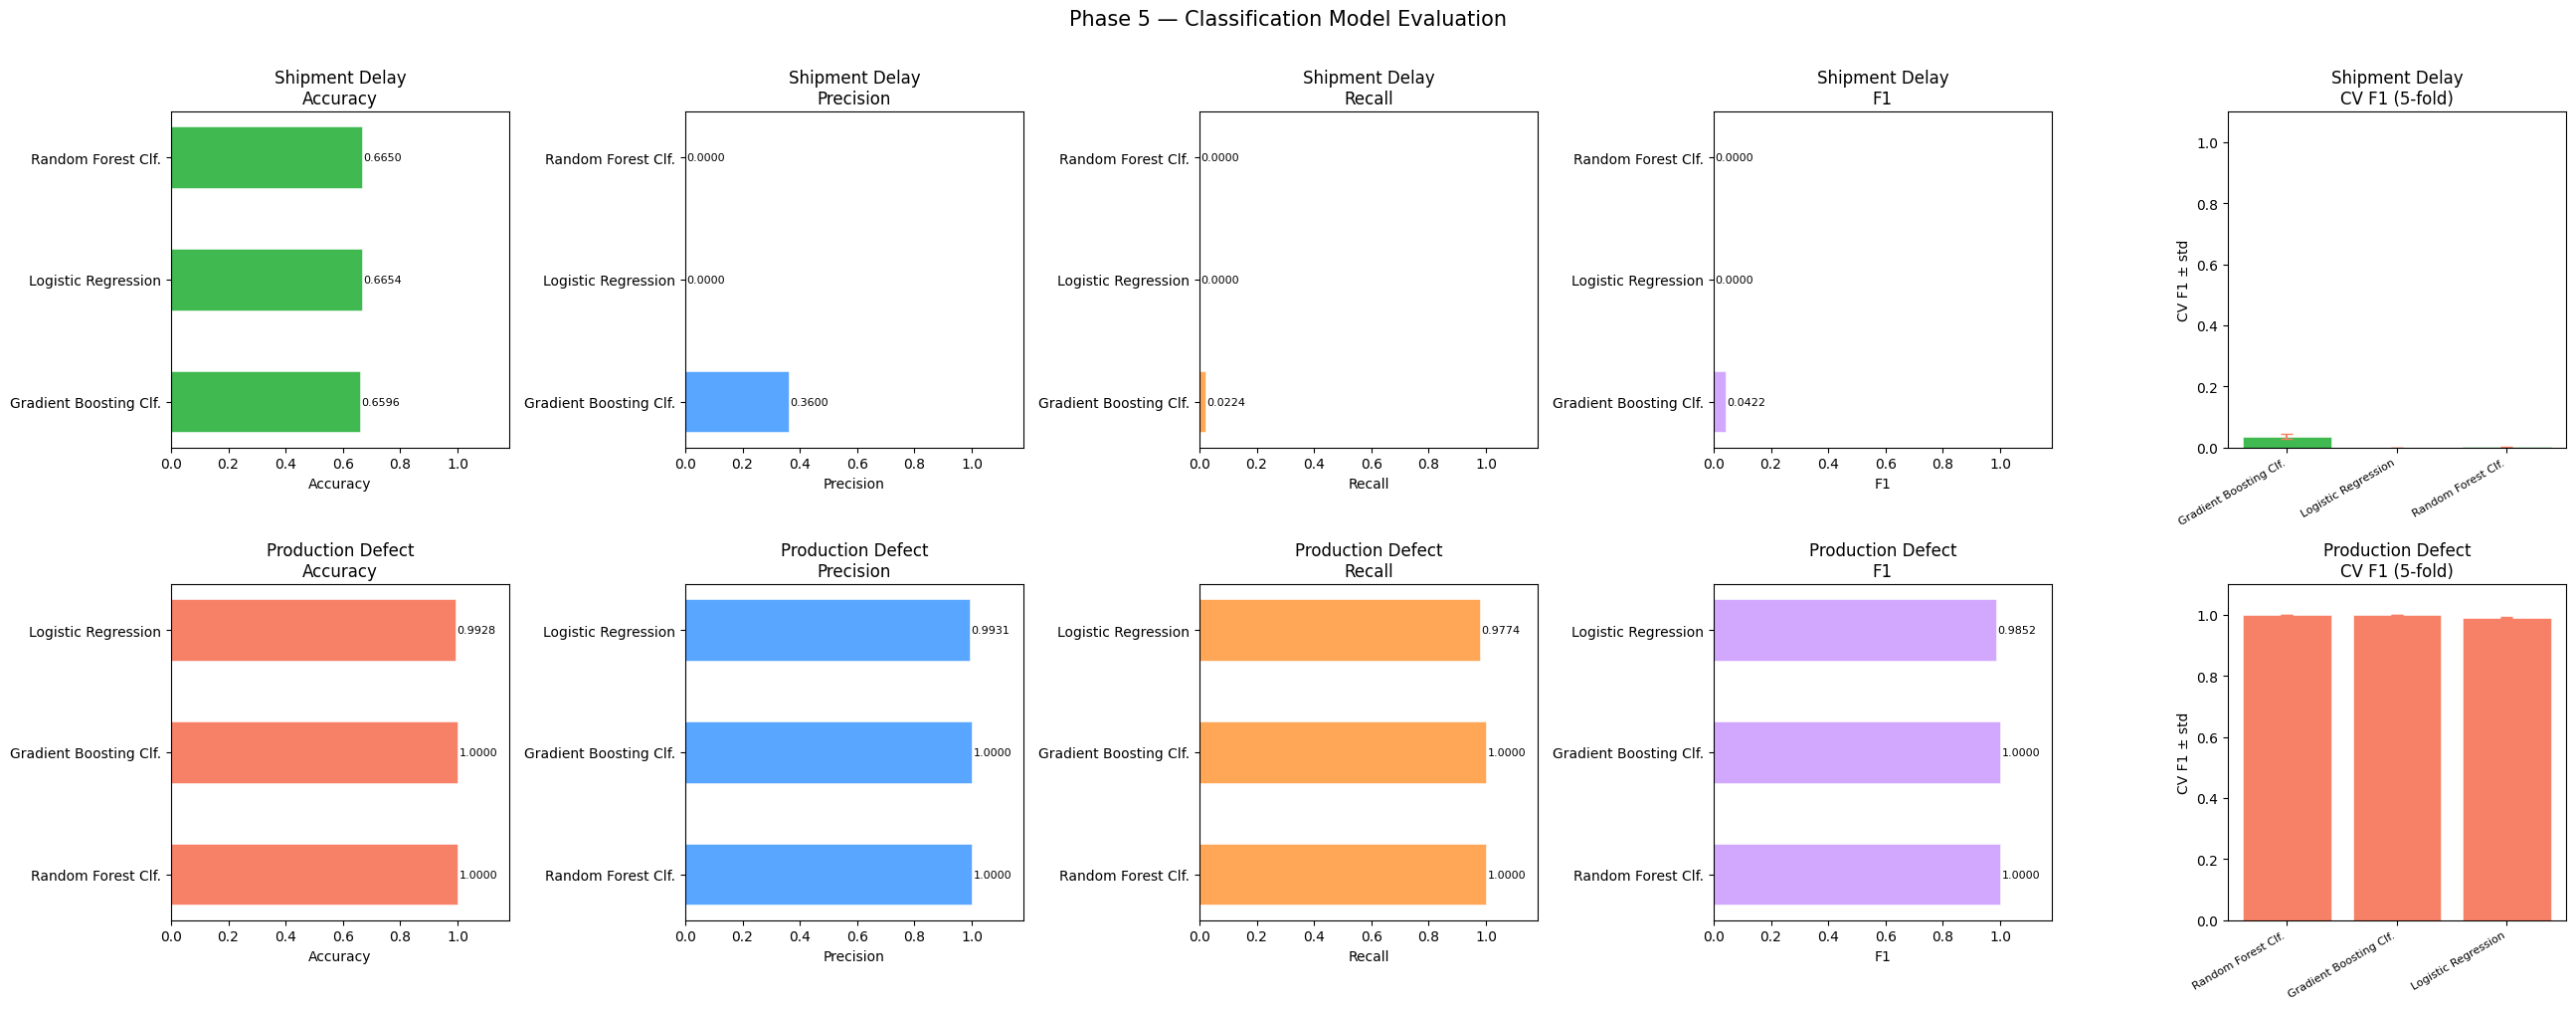

[Figure 23 - Classification Evaluation Metrics]


In [62]:
#  9.7 Classification evaluation plots 
fig, axes = plt.subplots(2, 5, figsize=(26, 10))

cls_tasks = [
    ('Shipment Delay',    ship_eval_df, ysh_te, ship_cls_probs, '#3FB950'),
    ('Production Defect', prod_eval_df, yp_te,  prod_cls_probs, '#F78166'),
]

for row_idx, (task_name, eval_df, y_true, probs_dict, color) in enumerate(cls_tasks):
    axr = axes[row_idx]

    for col_idx, (metric, m_color) in enumerate(zip(
            ['Accuracy','Precision','Recall','F1'],
            [color, '#58A6FF', '#FFA657', '#D2A8FF'])):
        bars = axr[col_idx].barh(eval_df['Model'], eval_df[metric],
                                  color=m_color, edgecolor='white',
                                  linewidth=0.4, height=0.5)
        for bar, val in zip(bars, eval_df[metric]):
            axr[col_idx].text(val + 0.005,
                              bar.get_y() + bar.get_height()/2,
                              f'{val:.4f}', va='center', fontsize=8, color='black')
        axr[col_idx].set_title(f'{task_name}\n{metric}')
        axr[col_idx].set_xlabel(metric)
        axr[col_idx].set_xlim(0, 1.18)

    # CV F1 with error bars
    x_pos = np.arange(len(eval_df))
    axr[4].bar(x_pos, eval_df['CV_F1_mean'],
               yerr=eval_df['CV_F1_std'],
               color=color, edgecolor='white', linewidth=0.4,
               error_kw={'ecolor':'#F78166','linewidth':1.5,'capsize':4})
    axr[4].set_xticks(x_pos)
    axr[4].set_xticklabels(eval_df['Model'], rotation=30, ha='right', fontsize=8)
    axr[4].set_title(f'{task_name}\nCV F1 (5-fold)')
    axr[4].set_ylabel('CV F1 ± std')
    axr[4].set_ylim(0, 1.1)

plt.suptitle('Phase 5 — Classification Model Evaluation', fontsize=15,
             color='black', y=1.01)
plt.tight_layout()
plt.show()
print('[Figure 23 - Classification Evaluation Metrics]')


**Figure: Phase 5 Classification Model Evaluation — All Metrics with Cross-Validation**

Two rows of five panels evaluate shipment delay and production defect classifiers across Accuracy, Precision, Recall, F1, and 5-fold cross-validation F1 with error bars. For the delay task, Recall is the priority metric (catching actual delays). For the defect task, both Precision and Recall matter equally since both missed defects and false alarms carry operational costs.

### 9.8 Per-Class Breakdown Heatmaps

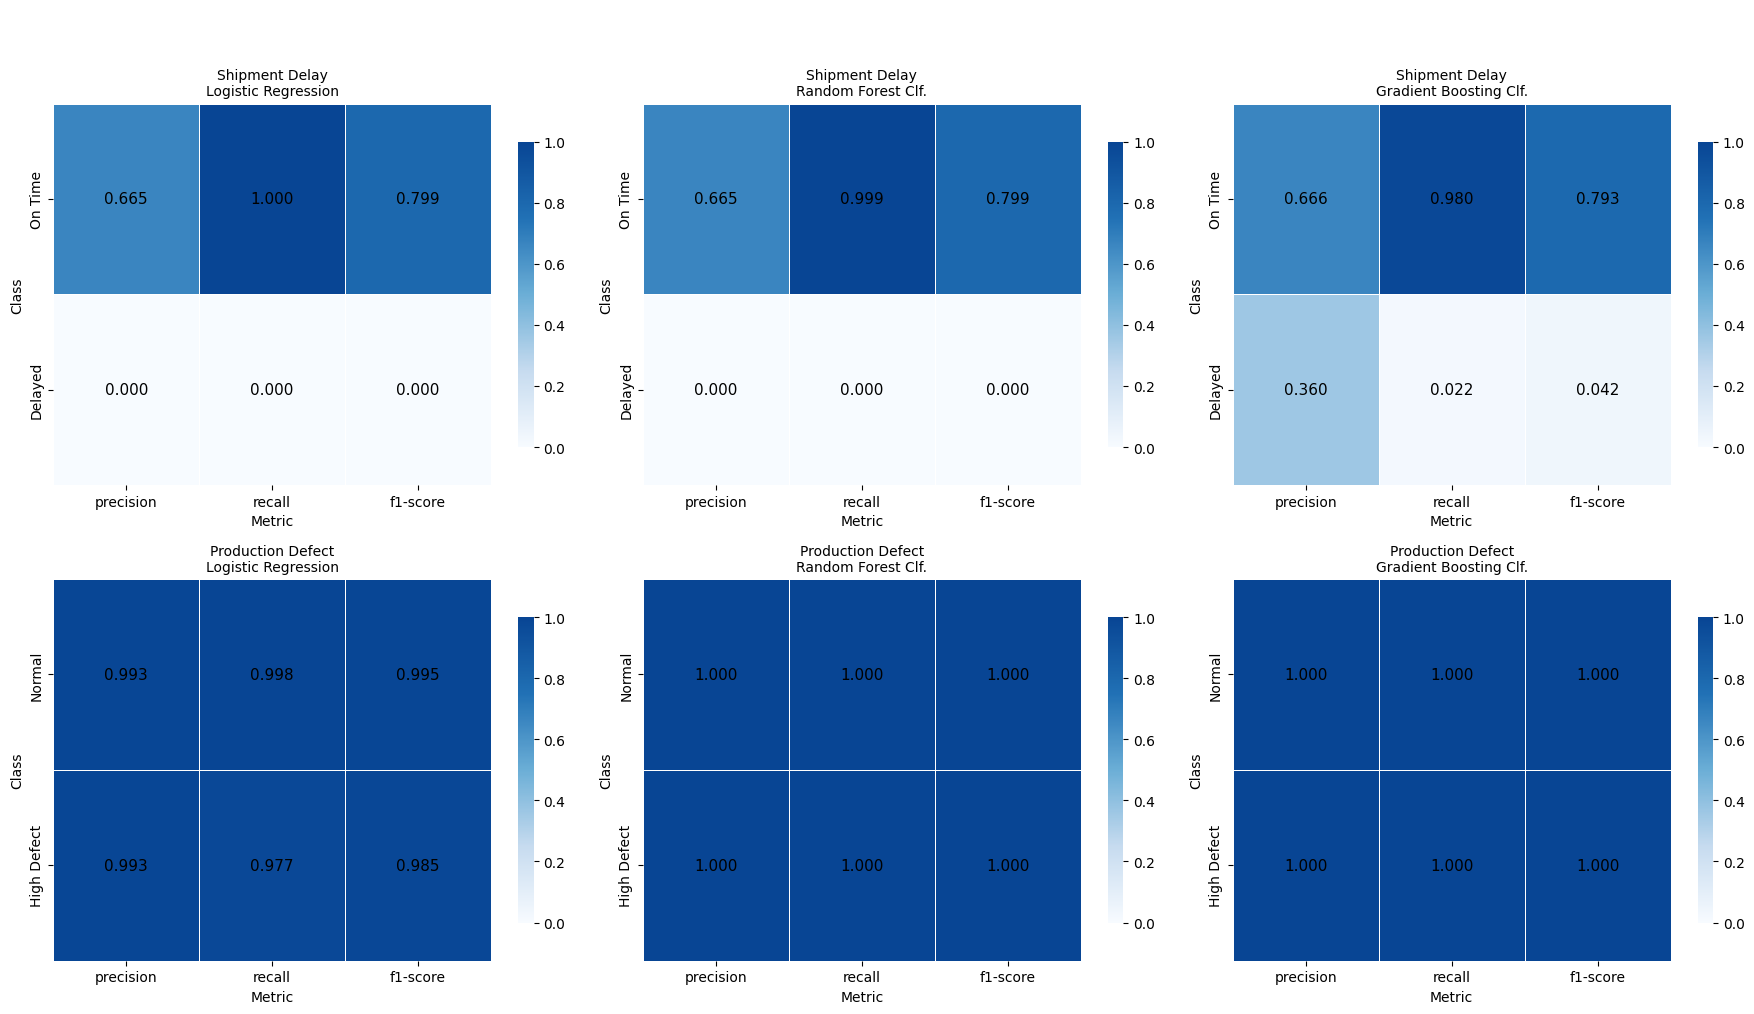

[Figure 24 - Per-Class Metric Heatmaps]


In [67]:
#  9.8 Per-class precision / recall heatmaps 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

cls_tasks_full = [
    ('Shipment Delay',    ship_cls_models, ship_cls_preds, ysh_te,
     ['On Time','Delayed'], axes[0]),
    ('Production Defect', prod_cls_models, prod_cls_preds, yp_te,
     ['Normal','High Defect'], axes[1]),
]

for task_name, models_dict, preds_dict, y_true, class_names, axrow in cls_tasks_full:
    for ax, (name, _) in zip(axrow, models_dict.items()):
        y_pred = preds_dict[name]
        report = classification_report(
            y_true, y_pred,
            target_names=class_names,
            output_dict=True, zero_division=0
        )
        report_df = pd.DataFrame(report).T.loc[class_names, ['precision','recall','f1-score']]
        report_df = report_df.astype(float)

        sns.heatmap(report_df, annot=True, fmt='.3f',
                    cmap=CMAP_LIGHT, ax=ax,
                    linewidths=0.5, linecolor='white',
                    annot_kws={'size':11, 'color':'black'},
                    vmin=0, vmax=1,
                    cbar_kws={'shrink':0.8})
        ax.set_title(f'{task_name}\n{name}', fontsize=10)
        ax.set_xlabel('Metric')
        ax.set_ylabel('Class')

plt.suptitle('Phase 5 — Per-Class Precision / Recall / F1 Heatmaps',
             fontsize=14, color="#FFFFFF", y=1.01)
plt.tight_layout()
plt.show()
print('[Figure 24 - Per-Class Metric Heatmaps]')


**Figure: Per-Class Precision, Recall, and F1 Heatmaps**

Each heatmap row corresponds to a class (On Time / Delayed for shipments; Normal / High Defect for production) and each column shows Precision, Recall, and F1 for that class. The colour scale ranges from 0 to 1. Comparing performance across classes reveals whether models are biased toward the majority class, which is a critical check for imbalanced classification tasks.

### 9.9 Clustering Evaluation — Silhouette Analysis

In [68]:
#  9.9 Full silhouette analysis 
from sklearn.metrics import silhouette_samples

print('=' * 70)
print('  PHASE 5 EVALUATION — CLUSTERING: SILHOUETTE ANALYSIS')
print('=' * 70)

cluster_configs = [
    ('Supplier — K-Means',      sup_scaled,  sup_km_labels,  BEST_K_SUP),
    ('Supplier — Hierarchical', sup_scaled,  sup_hc_labels,  BEST_K_SUP),
    ('Customer — K-Means',      cust_scaled, cust_km_labels, BEST_K_CUST),
    ('Customer — Hierarchical', cust_scaled, cust_hc_labels, BEST_K_CUST),
]

clust_eval_rows = []

for label, X, labels, k in cluster_configs:
    sil_avg    = silhouette_score(X, labels)
    sil_samp   = silhouette_samples(X, labels)
    clust_sizes = pd.Series(labels).value_counts().sort_index()

    print(f'\n  Config  : {label}')
    print(f'  k       : {k}')
    print(f'  Silhouette (avg)  = {sil_avg:.4f}')
    print(f'  Cluster sizes     : {clust_sizes.to_dict()}')
    for c in sorted(np.unique(labels)):
        c_sil = sil_samp[labels == c].mean()
        print(f'    Cluster {c}  size={( labels == c).sum():>4d}  avg silhouette={c_sil:.4f}')

    clust_eval_rows.append({
        'Config': label, 'k': k,
        'Silhouette': round(sil_avg,4),
        'Min_cluster_size': int(clust_sizes.min()),
        'Max_cluster_size': int(clust_sizes.max())
    })

clust_eval_df = pd.DataFrame(clust_eval_rows)
print('\n  Summary Table:')
print(clust_eval_df.to_string(index=False))


  PHASE 5 EVALUATION — CLUSTERING: SILHOUETTE ANALYSIS

  Config  : Supplier — K-Means
  k       : 2
  Silhouette (avg)  = 0.2659
  Cluster sizes     : {0: 6, 1: 4}
    Cluster 0  size=   6  avg silhouette=0.1987
    Cluster 1  size=   4  avg silhouette=0.3668

  Config  : Supplier — Hierarchical
  k       : 2
  Silhouette (avg)  = 0.2659
  Cluster sizes     : {0: 6, 1: 4}
    Cluster 0  size=   6  avg silhouette=0.1987
    Cluster 1  size=   4  avg silhouette=0.3668

  Config  : Customer — K-Means
  k       : 2
  Silhouette (avg)  = 0.1581
  Cluster sizes     : {0: 2, 1: 3}
    Cluster 0  size=   2  avg silhouette=0.1662
    Cluster 1  size=   3  avg silhouette=0.1528

  Config  : Customer — Hierarchical
  k       : 2
  Silhouette (avg)  = 0.1942
  Cluster sizes     : {0: 4, 1: 1}
    Cluster 0  size=   4  avg silhouette=0.2428
    Cluster 1  size=   1  avg silhouette=0.0000

  Summary Table:
                 Config  k  Silhouette  Min_cluster_size  Max_cluster_size
     Supplier — K-

### 9.10 Silhouette Plots

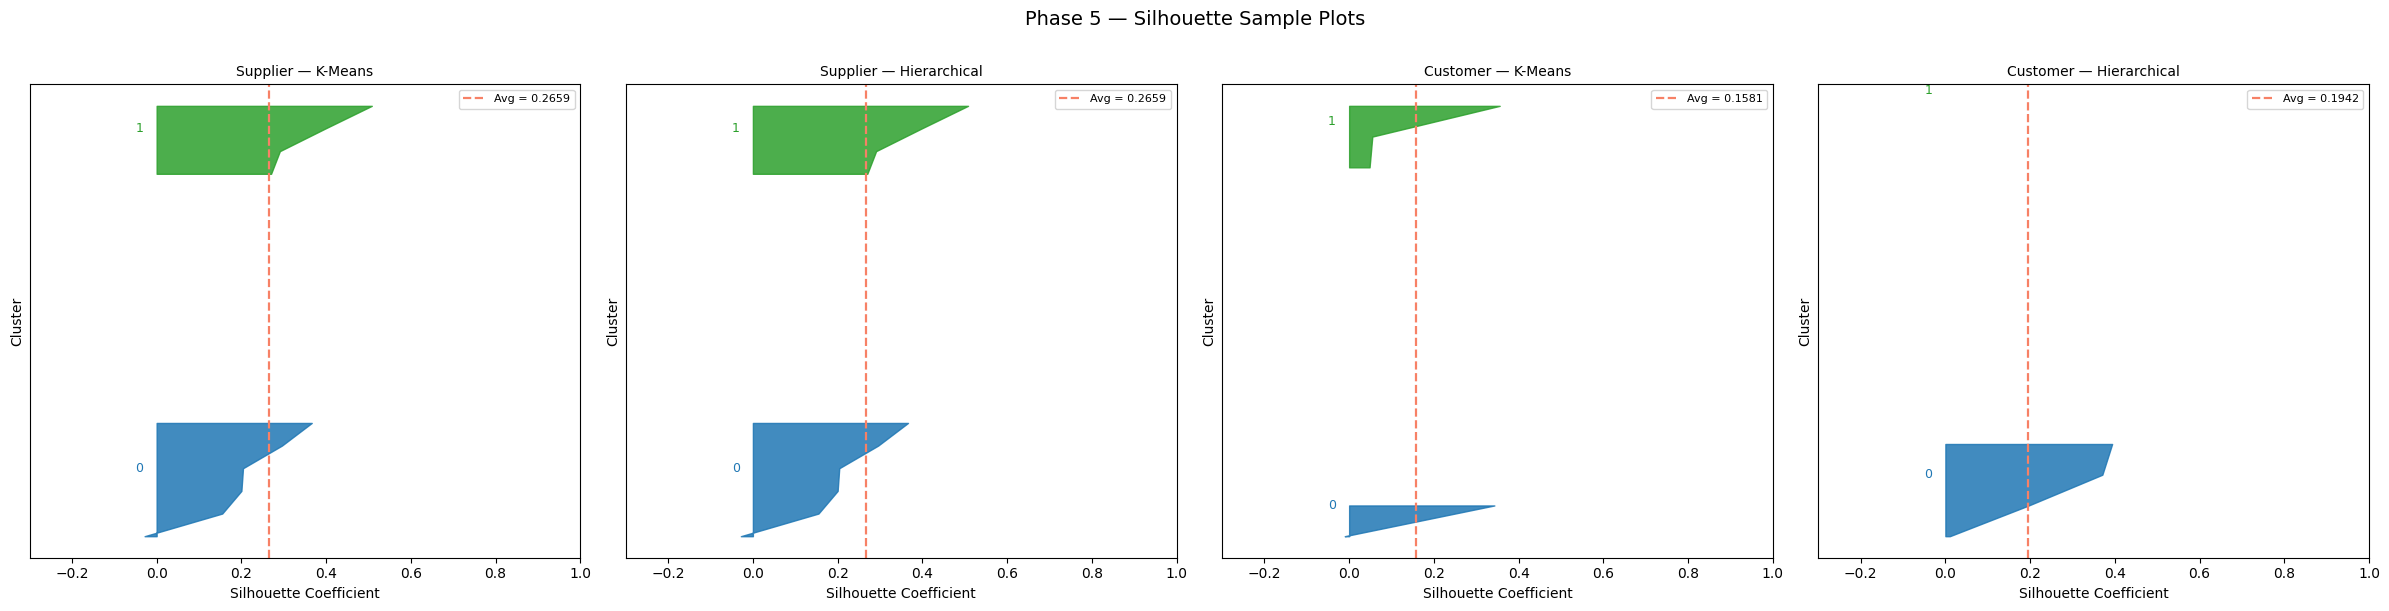

[Figure 25 - Silhouette Sample Plots]


In [69]:
#  9.10 Silhouette sample plots 
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, (label, X, labels, k) in zip(axes, cluster_configs):
    sil_samp = silhouette_samples(X, labels)
    sil_avg  = silhouette_score(X, labels)

    y_lower = 10
    for i in sorted(np.unique(labels)):
        c_sil = np.sort(sil_samp[labels == i])
        size  = len(c_sil)
        y_upper = y_lower + size

        color = LIGHT_PALETTE[i % len(LIGHT_PALETTE)]
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                         facecolor=color, edgecolor=color, alpha=0.85)
        ax.text(-0.05, y_lower + size/2, str(i), fontsize=9,
                color=color, va='center')
        y_lower = y_upper + 10

    ax.axvline(sil_avg, color='#F78166', linewidth=1.6, linestyle='--',
               label=f'Avg = {sil_avg:.4f}')
    ax.set_title(f'{label}', fontsize=10)
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cluster')
    ax.set_yticks([])
    ax.set_xlim(-0.3, 1.0)
    ax.legend(fontsize=8)

plt.suptitle('Phase 5 — Silhouette Sample Plots', fontsize=14,
             color='black', y=1.01)
plt.tight_layout()
plt.show()
print('[Figure 25 - Silhouette Sample Plots]')


**Figure: Silhouette Sample Plots for All Clustering Configurations**

Each panel shows a silhouette plot for one clustering configuration (Supplier K-Means, Supplier Hierarchical, Customer K-Means, Customer Hierarchical). Each horizontal bar represents one data point's silhouette coefficient — positive values indicate the point is well-matched to its cluster, while negative values indicate potential misassignment. The red dashed line marks the mean silhouette score.

### 9.11 Best Model Comparison — Normalised Radar

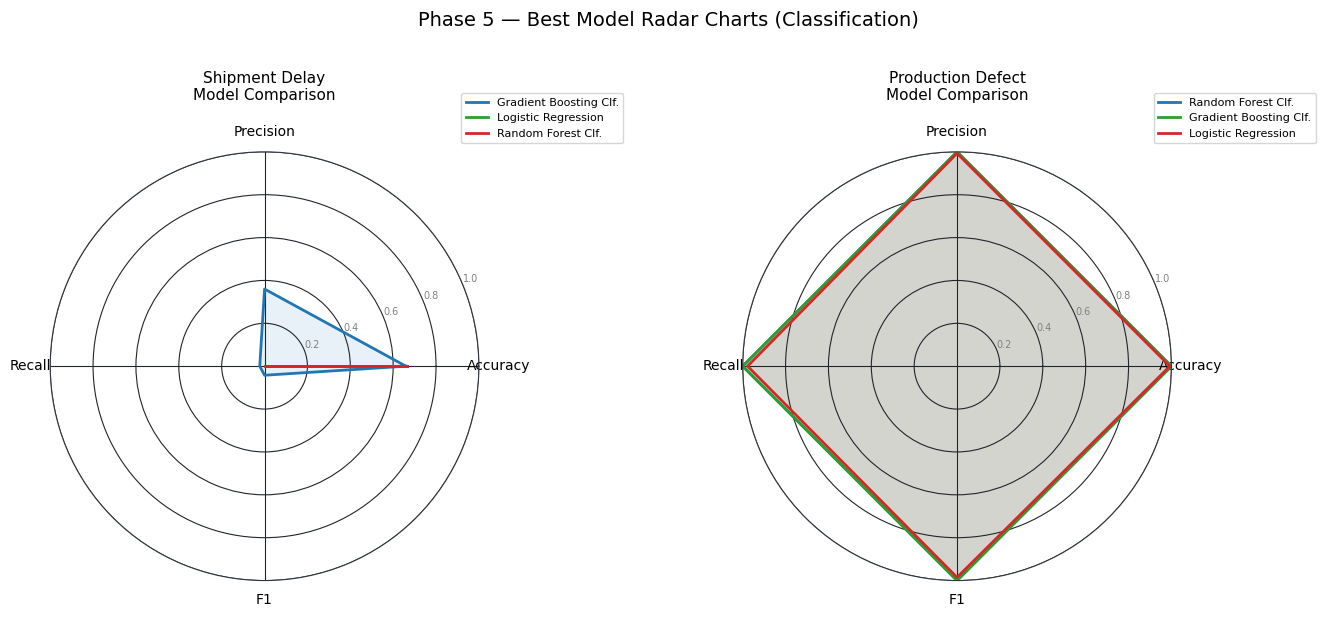

[Figure 26 - Best Model Radar Charts]


In [70]:
#  9.11 Best-model normalised radar chart 
# Compare best model from each task on normalised metrics

best_models_summary = {
    'Proc Cost\n(XGBoost)':    {'R2': proc_eval_df.iloc[0]['R2'],
                                  '1-MAPE': max(0, 1 - proc_eval_df.iloc[0]['MAPE(%)']/100),
                                  'CV_R2': proc_eval_df.iloc[0]['CV_R2_mean']},
    'Profit Margin\n(XGBoost)': {'R2': sales_eval_df.iloc[0]['R2'],
                                   '1-MAPE': max(0, 1 - sales_eval_df.iloc[0]['MAPE(%)']/100),
                                   'CV_R2': sales_eval_df.iloc[0]['CV_R2_mean']},
}

# 4-metric radar for classification best models
cls_metrics = ['Accuracy','Precision','Recall','F1']
n_metrics = len(cls_metrics)
angles = np.linspace(0, 2*np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                          subplot_kw=dict(polar=True))

for ax, (eval_df, task_name) in zip(axes, [
    (ship_eval_df, 'Shipment Delay'),
    (prod_eval_df, 'Production Defect')
]):
    for i, row in eval_df.iterrows():
        values = [row[m] for m in cls_metrics]
        values += values[:1]
        color = LIGHT_PALETTE[list(eval_df.index).index(i) % len(LIGHT_PALETTE)]
        ax.plot(angles, values, color=color, linewidth=2,
                label=row['Model'])
        ax.fill(angles, values, color=color, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(cls_metrics, color='black', fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2,0.4,0.6,0.8,1.0])
    ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], color='gray', fontsize=7)
    ax.grid(color='#21262D', linewidth=0.8)
    ax.spines['polar'].set_color('#30363D')
    ax.set_title(f'{task_name}\nModel Comparison', color='black',
                 pad=18, fontsize=11)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)

plt.suptitle('Phase 5 — Best Model Radar Charts (Classification)',
             fontsize=14, color='black', y=1.02)
plt.tight_layout()
plt.show()
print('[Figure 26 - Best Model Radar Charts]')


**Figure: Best Model Radar Charts — Classification Task Comparison**

Two spider charts compare all classifiers on four normalised metrics (Accuracy, Precision, Recall, F1) for the shipment delay and production defect tasks respectively. A model whose polygon covers the largest area across all axes is the most balanced performer. Asymmetric polygons indicate a model that sacrifices one metric (e.g. Precision) to maximise another (e.g. Recall).

### 9.12 Phase 5 Final Evaluation Dashboard

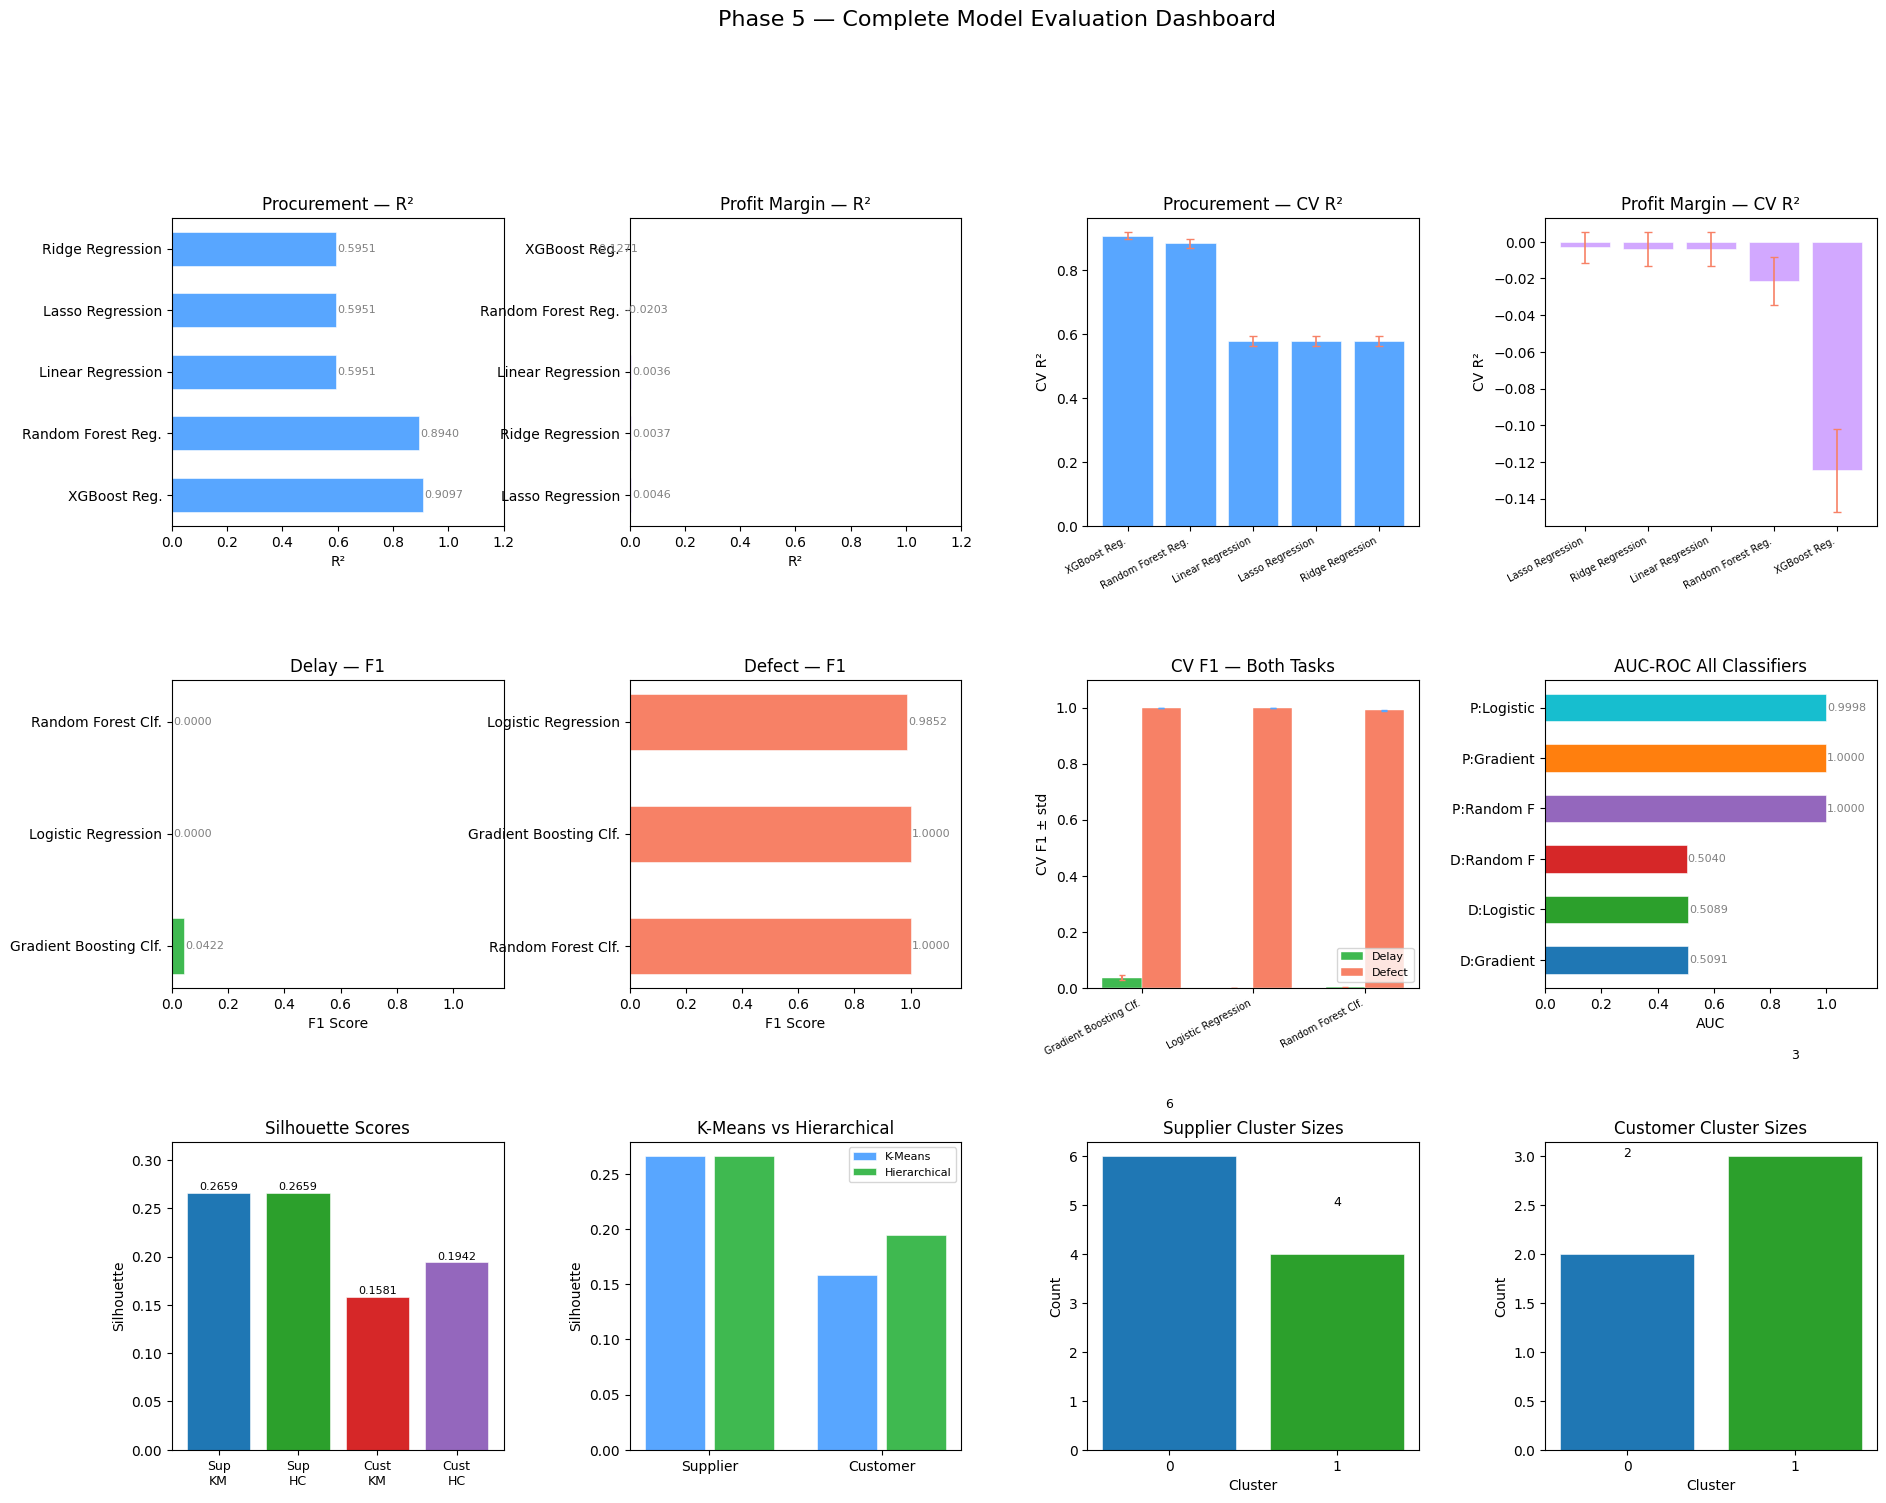

[Figure 27 - Final Evaluation Dashboard]


In [71]:
#  9.12 Phase 5 final evaluation dashboard 
fig = plt.figure(figsize=(22, 16))
gs  = fig.add_gridspec(3, 4, hspace=0.50, wspace=0.38)

#  Row 1: Regression R² and RMSE 
ax_r2_proc  = fig.add_subplot(gs[0, 0])
ax_r2_sales = fig.add_subplot(gs[0, 1])
ax_cv_proc  = fig.add_subplot(gs[0, 2])
ax_cv_sales = fig.add_subplot(gs[0, 3])

for ax, df, title, color in [
    (ax_r2_proc,  proc_eval_df,  'Procurement — R²',    '#58A6FF'),
    (ax_r2_sales, sales_eval_df, 'Profit Margin — R²',  '#D2A8FF'),
]:
    bars = ax.barh(df['Model'], df['R2'], color=color,
                   edgecolor='white', linewidth=0.4, height=0.55)
    for bar, val in zip(bars, df['R2']):
        ax.text(val+0.005, bar.get_y()+bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8, color='gray')
    ax.set_title(title)
    ax.set_xlabel('R²')
    ax.set_xlim(0, 1.2)

for ax, df, title, color in [
    (ax_cv_proc,  proc_eval_df,  'Procurement — CV R²',   '#58A6FF'),
    (ax_cv_sales, sales_eval_df, 'Profit Margin — CV R²', '#D2A8FF'),
]:
    x = np.arange(len(df))
    ax.bar(x, df['CV_R2_mean'], yerr=df['CV_R2_std'],
           color=color, edgecolor='white', linewidth=0.4,
           error_kw={'ecolor':'#F78166','capsize':3,'linewidth':1.2})
    ax.set_xticks(x)
    ax.set_xticklabels(df['Model'], rotation=28, ha='right', fontsize=7)
    ax.set_title(title)
    ax.set_ylabel('CV R²')

#  Row 2: Classification F1 and CV F1 
ax_f1_ship  = fig.add_subplot(gs[1, 0])
ax_f1_prod  = fig.add_subplot(gs[1, 1])
ax_cvf_ship = fig.add_subplot(gs[1, 2])
ax_auc      = fig.add_subplot(gs[1, 3])

for ax, df, title, color in [
    (ax_f1_ship, ship_eval_df, 'Delay — F1',   '#3FB950'),
    (ax_f1_prod, prod_eval_df, 'Defect — F1',  '#F78166'),
]:
    bars = ax.barh(df['Model'], df['F1'], color=color,
                   edgecolor='white', linewidth=0.4, height=0.5)
    for bar, val in zip(bars, df['F1']):
        ax.text(val+0.005, bar.get_y()+bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8, color='gray')
    ax.set_title(title)
    ax.set_xlabel('F1 Score')
    ax.set_xlim(0, 1.18)

# CV F1 grouped
x = np.arange(len(ship_eval_df))
w = 0.35
ax_cvf_ship.bar(x - w/2, ship_eval_df['CV_F1_mean'],
                yerr=ship_eval_df['CV_F1_std'], width=w,
                color='#3FB950', edgecolor='white', linewidth=0.3,
                label='Delay', error_kw={'ecolor':'#F78166','capsize':2})
ax_cvf_ship.bar(x + w/2, prod_eval_df['CV_F1_mean'],
                yerr=prod_eval_df['CV_F1_std'], width=w,
                color='#F78166', edgecolor='white', linewidth=0.3,
                label='Defect', error_kw={'ecolor':'#58A6FF','capsize':2})
ax_cvf_ship.set_xticks(x)
ax_cvf_ship.set_xticklabels(ship_eval_df['Model'], rotation=28, ha='right', fontsize=7)
ax_cvf_ship.set_title('CV F1 — Both Tasks')
ax_cvf_ship.set_ylabel('CV F1 ± std')
ax_cvf_ship.legend(fontsize=8)
ax_cvf_ship.set_ylim(0, 1.1)

# AUC comparison
auc_vals  = list(ship_eval_df['AUC']) + list(prod_eval_df['AUC'])
auc_names = [f'D:{m[:8]}' for m in ship_eval_df['Model']] +             [f'P:{m[:8]}' for m in prod_eval_df['Model']]
auc_colors = LIGHT_PALETTE[:len(auc_vals)]
bars = ax_auc.barh(auc_names, auc_vals, color=auc_colors,
                   edgecolor='white', linewidth=0.4, height=0.55)
for bar, val in zip(bars, auc_vals):
    ax_auc.text(val+0.003, bar.get_y()+bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8, color='gray')
ax_auc.set_title('AUC-ROC All Classifiers')
ax_auc.set_xlabel('AUC')
ax_auc.set_xlim(0, 1.18)

#  Row 3: Silhouette + cluster sizes 
ax_sil    = fig.add_subplot(gs[2, 0])
ax_scomp  = fig.add_subplot(gs[2, 1])
ax_sup_sz = fig.add_subplot(gs[2, 2])
ax_cst_sz = fig.add_subplot(gs[2, 3])

# Silhouette bar
sil_labels = clust_eval_df['Config']
sil_vals_e = clust_eval_df['Silhouette']
bars = ax_sil.bar(range(len(sil_labels)), sil_vals_e,
                  color=LIGHT_PALETTE[:len(sil_labels)],
                  edgecolor='white', linewidth=0.4)
for bar, val in zip(bars, sil_vals_e):
    ax_sil.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{val:.4f}', ha='center', fontsize=8, color='black')
ax_sil.set_xticks(range(len(sil_labels)))
ax_sil.set_xticklabels(['Sup\nKM','Sup\nHC','Cust\nKM','Cust\nHC'], fontsize=9)
ax_sil.set_title('Silhouette Scores')
ax_sil.set_ylabel('Silhouette')
ax_sil.set_ylim(0, max(sil_vals_e)*1.2)

# KM vs HC silhouette comparison
km_sil  = [sil_km, sil_km_c]
hc_sil  = [sil_hc, sil_hc_c]
x_comp  = np.arange(2)
ax_scomp.bar(x_comp - 0.2, km_sil, 0.35, color='#58A6FF',
             edgecolor='white', linewidth=0.4, label='K-Means')
ax_scomp.bar(x_comp + 0.2, hc_sil, 0.35, color='#3FB950',
             edgecolor='white', linewidth=0.4, label='Hierarchical')
ax_scomp.set_xticks(x_comp)
ax_scomp.set_xticklabels(['Supplier','Customer'])
ax_scomp.set_title('K-Means vs Hierarchical')
ax_scomp.set_ylabel('Silhouette')
ax_scomp.legend(fontsize=8)

# Cluster sizes
sup_sizes = pd.Series(sup_km_labels).value_counts().sort_index()
ax_sup_sz.bar(sup_sizes.index.astype(str), sup_sizes.values,
              color=LIGHT_PALETTE[:len(sup_sizes)], edgecolor='white', linewidth=0.4)
for i, val in enumerate(sup_sizes.values):
    ax_sup_sz.text(i, val+1, str(val), ha='center', fontsize=9, color='black')
ax_sup_sz.set_title('Supplier Cluster Sizes')
ax_sup_sz.set_xlabel('Cluster')
ax_sup_sz.set_ylabel('Count')

cust_sizes = pd.Series(cust_km_labels).value_counts().sort_index()
ax_cst_sz.bar(cust_sizes.index.astype(str), cust_sizes.values,
              color=LIGHT_PALETTE[:len(cust_sizes)], edgecolor='white', linewidth=0.4)
for i, val in enumerate(cust_sizes.values):
    ax_cst_sz.text(i, val+1, str(val), ha='center', fontsize=9, color='black')
ax_cst_sz.set_title('Customer Cluster Sizes')
ax_cst_sz.set_xlabel('Cluster')
ax_cst_sz.set_ylabel('Count')

fig.suptitle('Phase 5 — Complete Model Evaluation Dashboard',
             fontsize=16, color='black', y=1.01)


plt.show()
print('[Figure 27 - Final Evaluation Dashboard]')


**Figure: Phase 5 Complete Model Evaluation Dashboard**

A comprehensive nine-panel evaluation dashboard covering: regression R-squared and cross-validation R-squared for both tasks; classification F1 and cross-validation F1 with error bars for both tasks; AUC-ROC scores for all classifiers; silhouette score comparison across all clustering methods; and cluster size distributions for supplier and customer segments. This is the definitive model evaluation reference view.

### 9.13 Save Evaluation Results

In [67]:
#  9.13 Export all Phase 5 evaluation results 
os.makedirs('results', exist_ok=True)

proc_eval_df.to_csv('results/eval_procurement_regression.csv', index=False)
sales_eval_df.to_csv('results/eval_profit_margin_regression.csv', index=False)
ship_eval_df.to_csv('results/eval_shipment_delay_classification.csv', index=False)
prod_eval_df.to_csv('results/eval_defect_classification.csv', index=False)
clust_eval_df.to_csv('results/eval_clustering_silhouette.csv', index=False)

print('All Phase 5 evaluation tables saved to /results/')

#  Final printed report 
sep = '=' * 75
print()
print(sep)
print('  PHASE 5 — COMPLETE MODEL EVALUATION REPORT')
print(sep)

print('\n  REGRESSION MODELS')
print(f'  {"Model":<32} {"Task":<22} {"MAE":>10} {"RMSE":>10} {"R2":>8} {"CV_R2":>8}')
print('  ' + '-'*90)
for _, r in proc_eval_df.iterrows():
    print(f'  {r["Model"]:<32} {"Procurement":22} {r["MAE"]:>10.4f} {r["RMSE"]:>10.4f} {r["R2"]:>8.4f} {r["CV_R2_mean"]:>8.4f}')
for _, r in sales_eval_df.iterrows():
    print(f'  {r["Model"]:<32} {"Profit Margin":22} {r["MAE"]:>10.4f} {r["RMSE"]:>10.4f} {r["R2"]:>8.4f} {r["CV_R2_mean"]:>8.4f}')

print('\n  CLASSIFICATION MODELS')
print(f'  {"Model":<32} {"Task":<22} {"Acc":>7} {"Prec":>7} {"Rec":>7} {"F1":>7} {"AUC":>7} {"CV_F1":>7}')
print('  ' + '-'*96)
for _, r in ship_eval_df.iterrows():
    print(f'  {r["Model"]:<32} {"Shipment Delay":22} {r["Accuracy"]:>7.4f} {r["Precision"]:>7.4f} {r["Recall"]:>7.4f} {r["F1"]:>7.4f} {r["AUC"]:>7.4f} {r["CV_F1_mean"]:>7.4f}')
for _, r in prod_eval_df.iterrows():
    print(f'  {r["Model"]:<32} {"Defect Detection":22} {r["Accuracy"]:>7.4f} {r["Precision"]:>7.4f} {r["Recall"]:>7.4f} {r["F1"]:>7.4f} {r["AUC"]:>7.4f} {r["CV_F1_mean"]:>7.4f}')

print('\n  CLUSTERING')
print(f'  {"Config":<35} {"k":>4} {"Silhouette":>12}')
print('  ' + '-'*52)
for _, r in clust_eval_df.iterrows():
    print(f'  {r["Config"]:<35} {r["k"]:>4} {r["Silhouette"]:>12.4f}')
print(sep)


All Phase 5 evaluation tables saved to /results/

  PHASE 5 — COMPLETE MODEL EVALUATION REPORT

  REGRESSION MODELS
  Model                            Task                          MAE       RMSE       R2    CV_R2
  ------------------------------------------------------------------------------------------
  XGBoost Reg.                     Procurement            456693.4552 688709.9414   0.9097   0.9068
  Random Forest Reg.               Procurement            505003.6352 745917.7523   0.8940   0.8827
  Linear Regression                Procurement            1101499.4369 1458101.7163   0.5951   0.5773
  Lasso Regression                 Procurement            1101499.3345 1458101.6684   0.5951   0.5773
  Ridge Regression                 Procurement            1101447.0521 1458102.8484   0.5951   0.5773
  Lasso Regression                 Profit Margin             10.1449    11.6865   0.0046  -0.0031
  Ridge Regression                 Profit Margin             10.1479    11.6919   0.0037 